<h1 style="text-align: center; font-size: 40px; color: gray; font-weight: 700; margin-bottom: 5px;">
    FINAL PROJECT - DELTA
</h1>
<h2 style="text-align: center; font-weight: 500; margin-top: 0;">
    Use Case : Telco Customer Churn
</h2>

# **Outline**

- [**Section 0.** Import Library](#import-library)
- [**Section 1.** Business Understanding](#business-understanding)
- [**Section 2.** Data Understanding](#data-understanding)
- [**Section 3.** Data Cleaning](#data-cleaning)
- [**Section 4.** Feature Generation](#feature-generation)
- [**Section 5.** Data Anlysis](#data-analysis)
- [**Section 6.** Kesimpulan dan Rekomendasi](#kesimpulan-dan-rekomendasi)


# **IMPORT LIBRARY**

In [ ]:
#Basic Library
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc
import statsmodels as st

#Ignore Warning
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
pd.set_option('display.max_columns', None)

# **BUSINESS UNDERSTANDING**

## **BUSINESS OBJECTIVE**

Memahami dan menguantifikasi dampak finansial nyata dari perilaku pelanggan yang berhenti bertransaksi (churn). Hal ini bertujuan untuk memberikan landasan kuat bagi manajemen dalam memahami besaran dampak finansial serta menentukan apakah investasi atau biaya yang dikeluarkan untuk program retensi pelanggan benar-benar layak dan menguntungkan untuk dilakukan (feasible).

## **PROBLEM STATEMENT**

Overview:
Churn tidak hanya berdampak pada jumlah pelanggan tetapi juga pada kehilangan pendapatan.
Mengestimasi revenue loss dari pelanggan yang berhenti bertransaksi membantu manajemen
memahami besaran dampak finansial churn dan menentukan apakah investasi pada program
retensi benar-benar layak dilakukan.

Business Questions:
1.  Berapa total revenue yang hilang dari pelanggan yang churn.  
2.  Bagaimana rata-rata revenue per pelanggan churn dibanding pelanggan yang masih
aktif.  
3.  Segmen mana yang menyumbang revenue loss terbesar.  
4.  Berapa banyak pelanggan high-value yang churn.  
5.  Berapa kontribusi revenue yang hilang dari jenis layanan tertentu.  
6.  Apakah revenue loss didominasi pelanggan lama atau pelanggan baru.  
7.  Berapa perkiraan revenue yang hilang bila churn naik satu persen.

## **GOALS**

Business Goal :

Mengidentifikasi total kerugian pendapatan (Revenue Loss) akibat hilangnya pelanggan (churn) dan memetakan segmen layanan serta profil pelanggan yang memberikan dampak finansial negatif terbesar bagi perusahaan telekomunikasi.


Analysis Objectives:
1. ⁠Menghitung Total Finansial yang Hilang: Menghitung total potensi Monthly Charges yang hilang per bulan akibat pelanggan yang memilih Churn = Yes, serta melihat akumulasi kontribusi historis mereka pada TotalCharges.
2. ⁠Perbandingan Profil Finansial: Membandingkan rata-rata pengeluaran bulanan (MonthlyCharges) antara pelanggan yang churn dengan pelanggan yang tetap aktif (Churn = No).
3. ⁠Identifikasi Segmen Penyumbang Kerugian Terbesar: Menganalisis kelompok kontrak (Contract) atau metode pembayaran (PaymentMethod) mana yang paling banyak menyumbang revenue loss.
4. ⁠Analisis Pelanggan Bernilai Tinggi (High-Value Customers): Menentukan batas (threshold) tagihan untuk mendefinisikan siapa saja pelanggan high-value (misal: pelanggan dengan MonthlyCharges di atas kuartil 3 atau > 90$), lalu menghitung berapa banyak dari mereka yang churn beserta total kerugiannya.
5. ⁠Kontribusi Kerugian per Jenis Layanan: Menghitung kontribusi nilai kerugian berdasarkan jenis layanan yang digunakan pelanggan (apakah didominasi oleh pengguna internet Fiber Optic, DSL, atau pelanggan tanpa paket TechSupport).
6. ⁠Analisis Karakteristik Masa Berlangganan (Tenure): Mengelompokkan pelanggan (binning/bucketing) menjadi pelanggan baru (<_ 12 bulan) dan pelanggan lama (> 12 bulan) untuk melihat apakah revenue loss didominasi oleh kegagalan menjaga pelanggan baru atau hilangnya loyalitas pelanggan lama.

## **ANALYTICAL APPROACH**

Pendekatan analitik dimulai dengan proses **Exploratory Data Analysis (EDA)** sebagai fondasi utama untuk menjawab pertanyaan-pertanyaan pada problem statement. Analisis dilakukan dengan membandingkan pelanggan churn dan non-churn untuk mengukur besarnya revenue yang hilang akibat customer churn. Pendekatan ini mencakup perhitungan total revenue loss, analisis rata-rata kontribusi revenue pelanggan, serta identifikasi segmen pelanggan yang paling banyak menyumbang kerugian berdasarkan karakteristik tertentu seperti tenure, contract type, dan layanan yang digunakan. Hasil analisis digunakan untuk membantu perusahaan memahami dampak finansial churn dan menentukan prioritas strategi retensi pelanggan.

# **DATA UNDERSTANDING**

## **1. DATASET DESCRIPTION**

- [Sumber dataset: Kaggle Repository (Blashchar)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn).
- Jumlah baris: 7043 baris.
- Jumlah Kolom: 21 kolom.
- Periode: 2018.
- Tipe problem: Binary Classification (Customer Churn Analysis).

Note:
- Setiap baris data merepresentasikan informasi satu pelanggan layanan telekomunikasi.

| Nama Kolom             | Tipe Data       | Deskripsi                                                                            |
| :--------------------- | :-------------- | :----------------------------------------------------------------------------------- |
| **`customerID`**       | Identifier      | ID unik setiap pelanggan.                                                            |
| **`gender`**           | Binary          | Jenis kelamin pelanggan (Male/Female).                                               |
| **`SeniorCitizen`**    | Binary          | Apakah pelanggan termasuk lansia? (1 = yes, 0 = no).                                 |
| **`Partner`**          | Binary          | Apakah pelanggan memiliki pasangan? (yes/no).                                        |
| **`Dependents`**       | Binary          | Apakah pelanggan memiliki tanggungan? (yes/no).                                      |
| **`tenure`**           | Numerik         | Lama pelanggan berlangganan dalam satuan bulan.                                      |
| **`PhoneService`**     | Binary          | Apakah pelanggan menggunakan layanan telepon? (yes/no).                              |
| **`MultipleLines`**    | Kategorikal     | Status penggunaan lebih dari satu line telepon (yes, no, no phone service).          |
| **`InternetService`**  | Kategorikal     | Jenis layanan internet yang digunakan pelanggan (DSL, Fiber optic, No).              |
| **`OnlineSecurity`**   | Kategorikal     | Apakah pelanggan menggunakan layanan keamanan online (yes, no, no internet service). |
| **`OnlineBackup`**     | Kategorikal     | Apakah pelanggan menggunakan layanan backup online (yes, no, no internet service).   |
| **`DeviceProtection`** | Kategorikal     | Apakah pelanggan menggunakan perlindungan perangkat (yes, no, no internet service).  |
| **`TechSupport`**      | Kategorikal     | Apakah pelanggan menggunakan layanan dukungan teknis (yes, no, no internet service). |
| **`StreamingTV`**      | Kategorikal     | Apakah pelanggan menggunakan layanan streaming TV (yes, no, no internet service).    |
| **`StreamingMovies`**  | Kategorikal     | Apakah pelanggan menggunakan layanan streaming film (yes, no, no internet service).  |
| **`Contract`**         | Kategorikal     | Jenis kontrak pelanggan (month-to-month, one year, two year).                        |
| **`PaperlessBilling`** | Binary          | Apakah pelanggan menggunakan tagihan digital/paperless billing? (yes/no).            |
| **`PaymentMethod`**    | Kategorikal     | Metode pembayaran yang digunakan pelanggan.                                          |
| **`MonthlyCharges`**   | Numerik         | Total biaya bulanan yang dibayarkan pelanggan.                                       |
| **`TotalCharges`**     | Numerik         | Total keseluruhan biaya yang telah dibayarkan pelanggan selama berlangganan.         |
| **`Churn`**            | Binary (Target) | Target variabel: apakah pelanggan berhenti berlangganan? (yes/no).                   |


## **2. DATASET PREVIEW**

In [ ]:
#Load Dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
#Dataset General Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Catatan singkat: Terlihat perbedaan tipe data antara `MonthlyCharges` dan `TotalCharges` yang seharusnya keduanya memiliki tipe data yang sama yaitu *Float*

In [ ]:
#Statistical Summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**LOAD DATA SET TAMBAHAN**

In [ ]:
# Load ketiga file tambahan
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_val = pd.read_csv('validation.csv')

In [ ]:
# Gabungkan 3 data file ke bawah (concat vertikal)
df_tambahan = pd.concat([df_train, df_test, df_val], ignore_index=True)

# Cek apakah jumlah barisnya sudah mendekati/sama dengan 7 ribuan
print("Jumlah baris data gabungan:", df_tambahan.shape[0])

Jumlah baris data gabungan: 7043


In [ ]:
df_tambahan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                7043 non-null   int64  
 1   Avg Monthly GB Download            7043 non-null   int64  
 2   Avg Monthly Long Distance Charges  7043 non-null   float64
 3   Churn Category                     1869 non-null   object 
 4   Churn Reason                       1869 non-null   object 
 5   Churn Score                        7043 non-null   int64  
 6   City                               7043 non-null   object 
 7   CLTV                               7043 non-null   int64  
 8   Contract                           7043 non-null   object 
 9   Country                            7043 non-null   object 
 10  Customer ID                        7043 non-null   object 
 11  Customer Status                    7043 non-null   objec

In [ ]:
# Menyimpan df_tambahan menjadi file CSV baru
df_tambahan.to_csv('Telco_Churn_Tambahan.csv', index=False)

**MERGE DATASET UTAMA DENGAN DATASET TAMBAHAN**

In [ ]:
# kolom-kolom baru yang ingin dimasukkan + Kolom 'Customer ID' sebagai kunci
kolom_pilihan = [
    'Customer ID',                                       # Wajib untuk kunci penggabungan (merge)
    'Age', 'City', 'Population', 'Married',               # Demografi
    'Satisfaction Score', 'Avg Monthly GB Download', 'Offer', # Kontrak & Perilaku
    'Churn Reason',                                       # Alasan Churn
    'CLTV'
]
df_tambahan_mini = df_tambahan[kolom_pilihan]           # Ganti dengan nama variabel data 52 kolommu

# Gabungkan ke data utama memakai Merge (Left Join)
df_final = pd.merge(
    df,              # Nama variabel data utama kamu (yang 21 kolom)
    df_tambahan_mini,
    left_on='customerID',   # Nama kolom ID di data utama (huruf c kecil)
    right_on='Customer ID', # Nama kolom ID di data tambahan (huruf C besar)
    how='left'
)

# Hapus kolom ID yang duplikat biar rapi
df_final = df_final.drop(columns=['Customer ID'])

In [ ]:
df_tambahan_mini.head()

,Customer ID,Age,City,Population,Married,Satisfaction Score,Avg Monthly GB Download,Offer,Churn Reason,CLTV
0,4526-ZJJTM,72,San Mateo,37926,1,3,4,NaN,NaN,4849
1,5302-BDJNT,27,Sutter Creek,4610,0,3,59,NaN,NaN,3715
2,5468-BPMMO,59,Santa Cruz,4563,1,5,0,NaN,NaN,5092
3,2212-LYASK,25,Brea,1408,1,4,27,NaN,NaN,2068
4,0378-XSZPU,31,San Jose,29914,1,2,21,Offer B,Network reliability,4026


In [ ]:
df_final.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Age,City,Population,Married,Satisfaction Score,Avg Monthly GB Download,Offer,Churn Reason,CLTV
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,36,Los Angeles,54492,1,3,10,Offer E,NaN,3964
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,46,Los Angeles,44586,0,3,16,NaN,NaN,3441
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,37,Los Angeles,58198,0,1,21,NaN,Competitor made better offer,3239
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,53,Los Angeles,67852,0,3,10,NaN,NaN,4307
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,19,Los Angeles,43019,0,2,51,NaN,Moved,2701


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerID               7043 non-null   object 
 1   gender                   7043 non-null   object 
 2   SeniorCitizen            7043 non-null   int64  
 3   Partner                  7043 non-null   object 
 4   Dependents               7043 non-null   object 
 5   tenure                   7043 non-null   int64  
 6   PhoneService             7043 non-null   object 
 7   MultipleLines            7043 non-null   object 
 8   InternetService          7043 non-null   object 
 9   OnlineSecurity           7043 non-null   object 
 10  OnlineBackup             7043 non-null   object 
 11  DeviceProtection         7043 non-null   object 
 12  TechSupport              7043 non-null   object 
 13  StreamingTV              7043 non-null   object 
 14  StreamingMovies         

temuan dari info data set:
- Kolom **`TotalCharges`** (Tipe Data harusnya float64)
    Solusi: Ubah menjadi angka, lalu isi nilai kosong tersebut dengan angka 0 (karena mereka pelanggan baru yang tenure-nya masih 0). kemungkinan mendapat promo free trial sebelum mulai berlangganan
- Kolom **`Offer`** (Ada 3.877 Data Kosong / NaN)
    Solusi: Isi data NaN tersebut dengan label 'No Offer' agar tidak terbaca sebagai data hilang. krna tidak semua pelanggan mendapatkan promo atau penawaran (Offer) khusus saat mendaftar.
- Kolom **`Churn Reason`** (Ada 5.174 Data Kosong / NaN)
    Solusi: Isi data NaN tersebut dengan label 'No Churn'. karena alasan berhenti berlangganan hanya dimiliki oleh pelanggan yang Churn.
- Kolom **`Contract`** (Dtype harusnya category)
- Kolom **`Satisfaction Score`** (dtype harusnya category).
    Solusi : Ubah ke category akan mencegah Pandas memperlakukannya sebagai angka matematika murni, karena ini adalah skala kepuasan (data ordinal)
- Kolom **`Partner`**, **`Dependents`**, **`PhoneService`**, **`MultipleLines`**, **`PaperlessBilling`**, dan **`Churn`** (dtype harusnya category). Kolom Kategorikal Biner (Yes/No)
- Kolom **`SeniorCitizen`**, **`Married`** (Dtype harusnya category).
    Solusi : agar konsisten dengan kolom lain yang menggunakan kata 'Yes' dan 'No', kolom boolean (0 dan 1) ini diubah aja ke 'Yes' dan 'No'

# **DATA CLEANING**

## **1. DATA TYPE**

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerID               7043 non-null   object 
 1   gender                   7043 non-null   object 
 2   SeniorCitizen            7043 non-null   int64  
 3   Partner                  7043 non-null   object 
 4   Dependents               7043 non-null   object 
 5   tenure                   7043 non-null   int64  
 6   PhoneService             7043 non-null   object 
 7   MultipleLines            7043 non-null   object 
 8   InternetService          7043 non-null   object 
 9   OnlineSecurity           7043 non-null   object 
 10  OnlineBackup             7043 non-null   object 
 11  DeviceProtection         7043 non-null   object 
 12  TechSupport              7043 non-null   object 
 13  StreamingTV              7043 non-null   object 
 14  StreamingMovies         

In [ ]:
# Mengisi NaN
# 1. Churn Reason: Isi yang kosong dengan 'Not Churn'
df_final['Churn Reason'] = df_final['Churn Reason'].fillna('Not Churn')

# 2. Offer: Isi yang kosong dengan 'No Offer'
df_final['Offer'] = df_final['Offer'].fillna('No Offer')

In [ ]:
# 2. Ubah angka 1 dan 0 menjadi 'Yes' dan 'No' agar seragam
df_final['SeniorCitizen'] = df_final['SeniorCitizen'].map({1: 'Yes', 0: 'No'})
df_final['Married'] = df_final['Married'].map({1: 'Yes', 0: 'No'})

In [ ]:
#Data Type Conversion
df_final['TotalCharges'] = pd.to_numeric(df_final['TotalCharges'], errors='coerce')     # ke float64

cols = [                                                                   # ke category
     'SeniorCitizen', 'Married', #ubah 0/1 ke yes/no
     'Contract',                 #harus categorical
     'Satisfaction Score',       #skala kepuasan (data ordinal)
     'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
     'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
     'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
     'PaymentMethod', 'Churn', 'Offer', 'Satisfaction Score']
for i in cols:
     df_final[i] = df_final[i].astype('category')

# Cek ulang hasil cleaning
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   customerID               7043 non-null   object  
 1   gender                   7043 non-null   category
 2   SeniorCitizen            7043 non-null   category
 3   Partner                  7043 non-null   category
 4   Dependents               7043 non-null   category
 5   tenure                   7043 non-null   int64   
 6   PhoneService             7043 non-null   category
 7   MultipleLines            7043 non-null   category
 8   InternetService          7043 non-null   category
 9   OnlineSecurity           7043 non-null   category
 10  OnlineBackup             7043 non-null   category
 11  DeviceProtection         7043 non-null   category
 12  TechSupport              7043 non-null   category
 13  StreamingTV              7043 non-null   category
 14  Streamin

## **2.MISSING VALUE**

In [ ]:
#Check Missing Value
df_final.isna().sum().sort_values(ascending=False)

,0
TotalCharges,11
customerID,0
SeniorCitizen,0
Partner,0
Dependents,0
gender,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Menampilkan baris yang kolom TotalCharges-nya berisi NaN
df_final[df_final['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Age,City,Population,Married,Satisfaction Score,Avg Monthly GB Download,Offer,Churn Reason,CLTV
488,4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,43,San Bernardino,12149,Yes,3,20,No Offer,Not Churn,2578
753,3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,24,Independence,734,No,4,0,No Offer,Not Churn,5504
936,5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,40,San Mateo,32488,Yes,3,5,No Offer,Not Churn,2048
1082,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,39,Cupertino,54431,Yes,5,0,No Offer,Not Churn,4950
1340,1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,64,Redcrest,400,Yes,4,8,No Offer,Not Churn,4740
3331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,56,Los Angeles,41713,Yes,3,0,No Offer,Not Churn,2019
3826,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,22,Sun City,8692,Yes,4,0,No Offer,Not Churn,2299
4380,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,23,Ben Lomond,6407,Yes,4,0,Offer E,Not Churn,3763
5218,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,38,La Verne,35530,Yes,5,0,Offer E,Not Churn,4890
6670,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,25,Bell,105285,Yes,4,59,Offer E,Not Churn,2342


In [ ]:
kolom_intip = ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']
df_final[df_final['TotalCharges'].isnull()][kolom_intip]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


ke 11 baris yg total charge nya kosong (NaN) ini, mereka adalah pelanggan baru yang baru mendaftar di bulan itu (karena tenure-nya masih 0 bulan) dan belum melewati siklus penagihan pertama. (ini bukan data rusak/error jd tidak perlu di dropna).

In [ ]:
# Handle Missing Value

# impute dengan angka 0
df_final['TotalCharges'] = df_final['TotalCharges'].fillna(0)

# Recheck Missing Value
df_final.isna().sum().sort_values(ascending=False)

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## **3. DATA INCONSISTENCY**

In [ ]:
# 1. CEK INKONSISTENSI NILAI TEKS (Layanan Tambahan)
print("Memeriksa Nilai Unik pada Layanan Tambahan:\n")
kolom_layanan = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in kolom_layanan:
    print(f"- Nilai unik di kolom {col}: {df_final[col].unique()}\n")

Memeriksa Nilai Unik pada Layanan Tambahan:

- Nilai unik di kolom MultipleLines: ['No phone service', 'No', 'Yes']
Categories (3, object): ['No', 'No phone service', 'Yes']

- Nilai unik di kolom OnlineSecurity: ['No', 'Yes', 'No internet service']
Categories (3, object): ['No', 'No internet service', 'Yes']

- Nilai unik di kolom OnlineBackup: ['Yes', 'No', 'No internet service']
Categories (3, object): ['No', 'No internet service', 'Yes']

- Nilai unik di kolom DeviceProtection: ['No', 'Yes', 'No internet service']
Categories (3, object): ['No', 'No internet service', 'Yes']

- Nilai unik di kolom TechSupport: ['No', 'Yes', 'No internet service']
Categories (3, object): ['No', 'No internet service', 'Yes']

- Nilai unik di kolom StreamingTV: ['No', 'Yes', 'No internet service']
Categories (3, object): ['No', 'No internet service', 'Yes']

- Nilai unik di kolom StreamingMovies: ['No', 'Yes', 'No internet service']
Categories (3, object): ['No', 'No internet service', 'Yes']



In [ ]:
# 2. CEK INKONSISTENSI LOGIKA (Churn vs Churn Reason)
print("Memeriksa Logika Status Churn vs Alasan Churn:\n")
cross_churn = pd.crosstab(df_final['Churn'], df_final['Churn Reason'])
print(cross_churn)

# Validasi otomatis untuk Churn vs Churn Reason
inkonsisten_churn = df_final[(df_final['Churn'] == 'No') & (df_final['Churn Reason'] != 'Not Churn')].shape[0]
if inkonsisten_churn > 0:
    print(f"⚠️ PERINGATAN: Ada {inkonsisten_churn} baris data pelanggan TIDAK Churn tapi memiliki Alasan Churn!")
else:
    print("✅ Aman: Logika status Churn dan Alasan Churn sudah 100% konsisten.")

Memeriksa Logika Status Churn vs Alasan Churn:

Churn Reason  Attitude of service provider  Attitude of support person  \
Churn                                                                    
No                                       0                           0   
Yes                                     94                         220   

Churn Reason  Competitor had better devices  Competitor made better offer  \
Churn                                                                       
No                                        0                             0   
Yes                                     313                           311   

Churn Reason  Competitor offered higher download speeds  \
Churn                                                     
No                                                    0   
Yes                                                 100   

Churn Reason  Competitor offered more data  Deceased  Don't know  \
Churn                                    

In [ ]:
# 3. CEK INKONSISTENSI LOGIKA INTERNET (InternetService vs Avg Monthly GB Download)
print("\nMemeriksa Pengguna Tanpa Internet vs Kuota Download GB:")
kondisi_internet_salah = (df_final['InternetService'] == 'No') & (df_final['Avg Monthly GB Download'] > 0)
jumlah_int_salah = df_final[kondisi_internet_salah].shape[0]
if jumlah_int_salah > 0:
    print(f"⚠️ PERINGATAN: Ada {jumlah_int_salah} pelanggan yang TIDAK langganan internet tapi punya histori download GB!")
else:
    print("✅ Aman: Tidak ada aktivitas download gaib pada pelanggan non-internet.")


Memeriksa Pengguna Tanpa Internet vs Kuota Download GB:
✅ Aman: Tidak ada aktivitas download gaib pada pelanggan non-internet.


In [ ]:
# 4. CEK STANDAR PENULISAN NAMA KOTA (City)
print("\nMemeriksa Standarisasi Nama Kota:")
print(f"    - Jumlah total nama kota unik saat ini: {df_final['City'].nunique()}")
print("    - Menjalankan `.str.strip()` otomatis untuk menghapus spasi gaib di awal/akhir nama kota...")
df_final['City'] = df_final['City'].str.strip()
print(f"    - Jumlah total nama kota unik setelah dibersihkan: {df_final['City'].nunique()}")

print("\n=== FINISHED DATA INCONSISTENCY CHECK ===")


Memeriksa Standarisasi Nama Kota:
    - Jumlah total nama kota unik saat ini: 1106
    - Menjalankan `.str.strip()` otomatis untuk menghapus spasi gaib di awal/akhir nama kota...
    - Jumlah total nama kota unik setelah dibersihkan: 1106

=== FINISHED DATA INCONSISTENCY CHECK ===


In [ ]:
# 1. Cek jumlah total kota unik yang terdaftar
print("Total jumlah kota unik:", df_final['City'].nunique())

# 2. Intip 20 nama kota pertama secara alfabetis untuk melihat apakah ada typo/huruf kecil
print("\nContoh 20 nama kota pertama (Urut Alfabet):")
print(df_final['City'].sort_values().unique()[:20])

Total jumlah kota unik: 1106

Contoh 20 nama kota pertama (Urut Alfabet):
['Acampo' 'Acton' 'Adelanto' 'Adin' 'Agoura Hills' 'Aguanga' 'Ahwahnee'
 'Alameda' 'Alamo' 'Albany' 'Albion' 'Alderpoint' 'Alhambra' 'Aliso Viejo'
 'Alleghany' 'Alpaugh' 'Alpine' 'Alta' 'Altadena' 'Alturas']


## **4. DATA DUPLICATE**

In [ ]:
#Check Data Duplicate
duplicate_count = df_final.duplicated().sum()
duplicate_percent = (duplicate_count / len(df_final)) * 100
duplicate_rows = df_final[df_final.duplicated(keep=False)].sort_values(by=list(df_final.columns))

print(f"Total Baris Duplikat: {duplicate_count}")
print(f"Persentase dari Total Data: {duplicate_percent:.4f}%")
print("\nSampel Pasangan Data Duplikat:")
display(duplicate_rows)

Total Baris Duplikat: 0
Persentase dari Total Data: 0.0000%

Sampel Pasangan Data Duplikat:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Age,City,Population,Married,Satisfaction Score,Avg Monthly GB Download,Offer,Churn Reason,CLTV


## **5.OUTLIERS DETECTION**

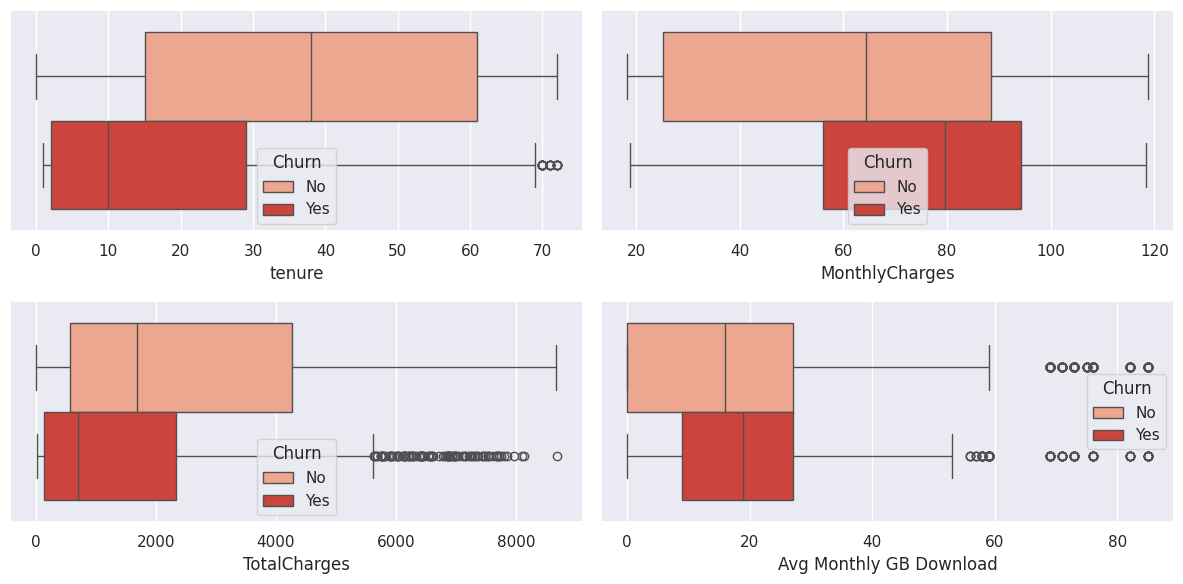


Analisis Outliers untuk Kolom: tenure
----------------------------------------
Churn = No | Jumlah Outliers: 0
Churn = Yes | Jumlah Outliers: 23

Analisis Outliers untuk Kolom: MonthlyCharges
----------------------------------------
Churn = No | Jumlah Outliers: 0
Churn = Yes | Jumlah Outliers: 0

Analisis Outliers untuk Kolom: TotalCharges
----------------------------------------
Churn = No | Jumlah Outliers: 0
Churn = Yes | Jumlah Outliers: 109

Analisis Outliers untuk Kolom: Avg Monthly GB Download
----------------------------------------
Churn = No | Jumlah Outliers: 278
Churn = Yes | Jumlah Outliers: 147


In [ ]:
numeric_cols = [
    'tenure',                    #(Masa berlangganan dalam bulan)
    'MonthlyCharges',           #(Biaya tagihan bulanan)
    'TotalCharges',             #(Total seluruh tagihan)
    'Avg Monthly GB Download',  #(Rata-rata kuota download bulanan)
    ]

plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df_final, x=col, palette='Reds', hue='Churn')

plt.tight_layout()
plt.show()

outliers_report = {}

for col in numeric_cols:
    print(f"\nAnalisis Outliers untuk Kolom: {col}")
    print("-" * 40)

    # Looping berdasarkan kategori Churn (Yes dan No)
    for churn_status in df_final['Churn'].unique():
        # Filter data per kelompok
        df_group = df_final[df_final['Churn'] == churn_status]

        Q1 = df_group[col].quantile(0.25)
        Q3 = df_group[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df_group[(df_group[col] < lower_bound) | (df_group[col] > upper_bound)]
        print(f"Churn = {churn_status} | Jumlah Outliers: {len(outliers)}")

**Temuan Analisis Outlier:**

1. **Variabel Tenure & Total Charges:**
   * Distribusi data pada kedua variabel ini menunjukkan sebaran nilai yang sangat lebar namun tetap berada dalam batas rentang yang wajar secara bisnis.
   * **Tidak ditemukan adanya pencilan (outlier) ekstrem** yang bersifat anomali atau indikasi salah input data. Variasi nilai yang tinggi pada `Total Charges` merupakan cerminan logis dari akumulasi tagihan pelanggan yang memiliki masa retensi (*tenure*) panjang dengan paket layanan bernilai tinggi.

2. **Variabel Monthly Charges:**
   * Melalui inspeksi boxplot, variabel `Monthly Charges` juga menunjukkan sebaran data yang bersih, homogen, dan bebas dari titik pencilan (*outlier*).
  
3. **`Avg Monthly GB Download`**
    Ada 362 pelanggan yang kuota download bulannya jauh lebih tinggi di atas rata-rata pelanggan normal.
    Ini bukan data eror/rusak. mereka mungkin adalah pengguna kelas berat (heavy user).
    ex: orang yang hobi streaming 4K, gamer, atau pelaku usaha kecil yang butuh internet kencang.


Karena seluruh data numerik bersifat valid secara natural bisnis dan **tidak mendeteksi adanya data rusak/pencilan ekstrem**, tim memutuskan untuk **tidak melakukan pemotongan (trimming) atau penghapusan data**. Seluruh baris data dipertahankan secara utuh (100%) untuk menjaga keakuratan hasil analisis dampak finansial pada tahapan berikutnya.

# **FEATURE GENERATION**

## **Membuat Kolom Kategorisasi (`Customer_Value_Segment`)**

In [ ]:
# Menentukan batasan kuartil dari kolom MonthlyCharges
q1 = df_final['MonthlyCharges'].quantile(0.25)  # Batas 25% terbawah
q3 = df_final['MonthlyCharges'].quantile(0.75)  # Batas 75% (atau top 25% teratas)

# Membuat fungsi logika untuk pembagian kategori
def segmentasi_pelanggan(charge):
    if charge <= q1:
        return 'Low-Value'
    elif charge >= q3:
        return 'High-Value'
    else:
        return 'Mid-Value'

#Hasil
print("--- INFORMASI BATASAN SEGMENTASI ---")
print(f"Low-Value  : Nilai MonthlyCharges <= ${q1:.2f}")
print(f"Mid-Value  : Nilai MonthlyCharges di antara ${q1:.2f} dan ${q3:.2f}")
print(f"High-Value : Nilai MonthlyCharges >= ${q3:.2f}\n")

# Membuat kolom baru hasil Feature Generation
df_final['Customer_Value_Segment'] = df_final['MonthlyCharges'].apply(segmentasi_pelanggan)

# Mengubah kolom baru tersebut menjadi tipe category dengan urutan yang logis
kategori_order = ['Low-Value', 'Mid-Value', 'High-Value']
df_final['Customer_Value_Segment'] = pd.Categorical(df_final['Customer_Value_Segment'], categories=kategori_order, ordered=True)

--- INFORMASI BATASAN SEGMENTASI ---
Low-Value  : Nilai MonthlyCharges <= $35.50
Mid-Value  : Nilai MonthlyCharges di antara $35.50 dan $89.85
High-Value : Nilai MonthlyCharges >= $89.85



## **Membuat Kolom Kategorisasi (`Customer_Status`)**

In [ ]:
def customer_status(tenure):
    if tenure <= 12:
        return 'New Customer'
    else:
        return 'Old Customer'

df_final['Customer_Status'] = df_final['tenure'].apply(customer_status)

print(f'New Customer : tenure (lama pelanggan berlangganan) <= 12')
print(f'Old Customer : tenure (lama pelanggan berlangganan) > 12')

New Customer : tenure (lama pelanggan berlangganan) <= 12
Old Customer : tenure (lama pelanggan berlangganan) > 12


## **Membuat Kolom Kategorisasi (`Age_Group`)**

In [ ]:
# Buat Kelompok umur (binning)
# Batasan Umur: Under 30, Productive Age 30-64, Senior Citizen 65+
bins = [0, 29, 64, df_final['Age'].max()]
labels = ['Under 30', 'Productive Age (30-64)', 'Senior Citizen (65+)']

# Masukkan ke kolom baru bernama 'Age_Group'
df_final['Age_Group'] = pd.cut(df_final['Age'], bins=bins, labels=labels)

print(f'Under 30 : Age <= 29')
print(f'Productive Age (30-64) : Age di antara 30 dan 64')
print(f'Senior Citizen (65+) : Age >= 65')

Under 30 : Age <= 29
Productive Age (30-64) : Age di antara 30 dan 64
Senior Citizen (65+) : Age >= 65


## **Membuat Kolom Kategorisasi (`Customer_Profile`)**

In [ ]:
# MEMBUAT SEGMEN PROFIL (SINGLE VS HOUSEHOLD)
# Logika: Jika Married='Yes' ATAU Dependents='Yes' -> Household, sisanya Single. krn mereka sudah tidak hidup sendiri lagi (punya pasangan/istri/suami)
def segmentasi_keluarga(row):
    if row['Married'] == 'Yes' or row['Dependents'] == 'Yes':
        return 'Household (Keluarga)'
    else:
        return 'Single (Individu Tunggal)'

# Buat kolom baru bernama 'Customer_Profile'
df_final['Customer_Profile'] = df_final.apply(segmentasi_keluarga, axis=1)

print("=== Segmentasi ===\n")
print(pd.crosstab(
    df_final['Customer_Profile'],
    [df_final['Married'], df_final['Dependents']],
    rownames=['Profil Hasil Segmen'],
    colnames=['Married', 'Dependents']
))

=== Segmentasi ===

Married                      No        Yes      
Dependents                   No  Yes    No   Yes
Profil Hasil Segmen                             
Household (Keluarga)          0  361  1653  1749
Single (Individu Tunggal)  3280    0     0     0


## **Membuat Kolom Kategorisasi (`Area_Type`)**

In [ ]:
# MENGELOMPOKKAN POPULASI (AREA TYPE)
# ==========================================
# Kita bagi kolom Population menjadi 3 bagian sama rata (Low, Medium, High)
# Menggunakan pd.qcut agar pembagian jumlah barisnya seimbang secara statistik
df_final['Area_Type'] = pd.qcut(
    df_final['Population'],
    q=3,
    labels=['Rural (Pedesaan/Kota Kecil)', 'Suburban (Pinggiran Kota)', 'Urban (Metropolitan/Kota Besar)']
)

# Intip 10 baris data secara acak untuk melihat kolom baru 'Area_Type'
df_final[['City', 'Population', 'Area_Type']].sample(10, random_state=42)

,City,Population,Area_Type
185,Glendale,9864,Suburban (Pinggiran Kota)
2715,Petaluma,35419,Urban (Metropolitan/Kota Besar)
3825,Menifee,14068,Suburban (Pinggiran Kota)
1807,Long Beach,37417,Urban (Metropolitan/Kota Besar)
132,Bellflower,72893,Urban (Metropolitan/Kota Besar)
1263,Fulton,476,Rural (Pedesaan/Kota Kecil)
3732,Yucca Valley,20486,Suburban (Pinggiran Kota)
1672,Los Angeles,68701,Urban (Metropolitan/Kota Besar)
811,Miramonte,571,Rural (Pedesaan/Kota Kecil)
2526,Brisbane,3635,Rural (Pedesaan/Kota Kecil)


# **DATA ANALYSIS**

## **1. Berapa revenue yang hilang dari pelanggan yang churn.**

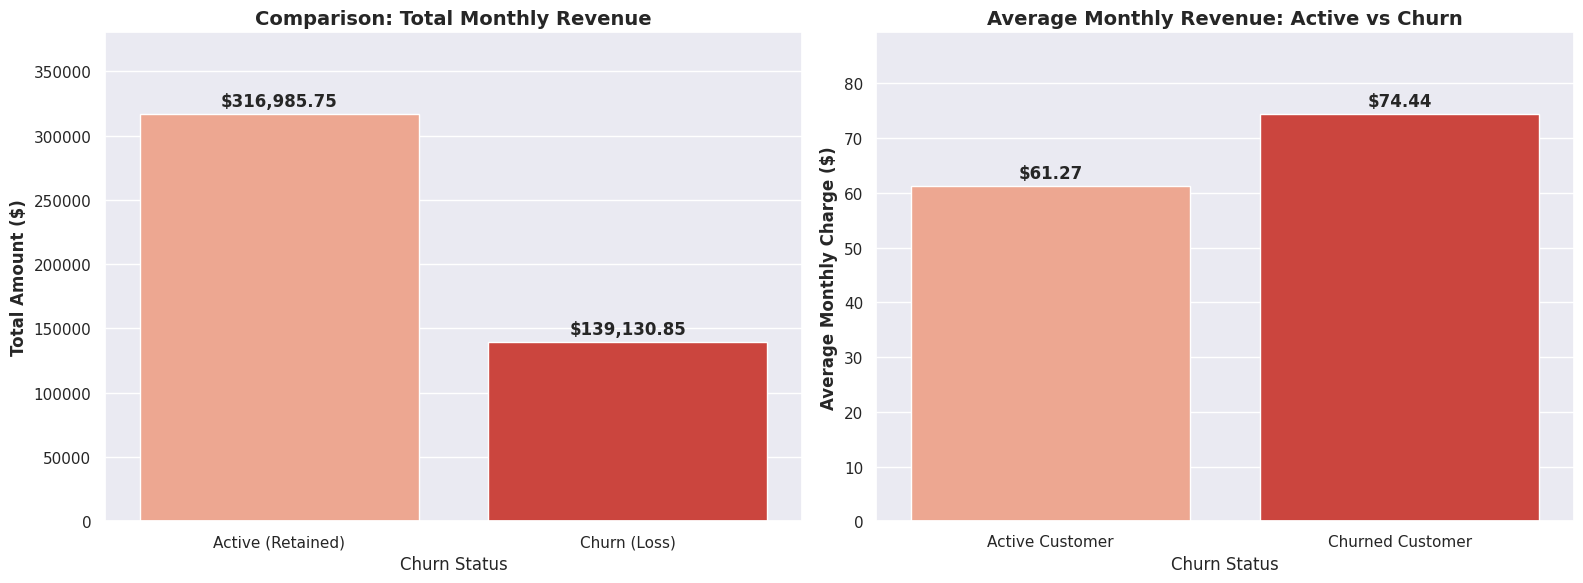

In [ ]:
# 1. Prepare the data for Total Revenue Comparison
revenue_comparison = df_final.groupby('Churn')['MonthlyCharges'].sum().reset_index()
revenue_comparison.columns = ['Churn Status', 'Total Monthly Revenue']
revenue_comparison['Churn Status'] = revenue_comparison['Churn Status'].map({'Yes': 'Churn (Loss)', 'No': 'Active (Retained)'})

# 2. Prepare the data for Average Revenue Comparison
avg_revenue = df_final.groupby('Churn')['MonthlyCharges'].mean().reset_index()
avg_revenue.columns = ['Churn Status', 'Average Monthly Charge']
avg_revenue['Churn Status'] = avg_revenue['Churn Status'].map({'Yes': 'Churned Customer', 'No': 'Active Customer'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Total Monthly Revenue
sns.barplot(x='Churn Status', y='Total Monthly Revenue', data=revenue_comparison, palette='Reds', ax=axes[0])
for i in axes[0].containers:
    axes[0].bar_label(i, fmt='${:,.2f}', fontweight='bold', padding=3)
axes[0].set_title('Comparison: Total Monthly Revenue', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Amount ($)', fontweight='bold')
axes[0].set_ylim(0, revenue_comparison['Total Monthly Revenue'].max() * 1.2)

# Plot B: Average Monthly Revenue
sns.barplot(x='Churn Status', y='Average Monthly Charge', data=avg_revenue, palette='Reds', ax=axes[1])
for i in axes[1].containers:
    axes[1].bar_label(i, fmt='${:,.2f}', fontweight='bold', padding=3)
axes[1].set_title('Average Monthly Revenue: Active vs Churn', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Monthly Charge ($)', fontweight='bold')
axes[1].set_ylim(0, avg_revenue['Average Monthly Charge'].max() * 1.2)

plt.tight_layout()
plt.show()

**Kesimpulan:**

Berdasarkan chart tersebut, terlihat bahwa Revenue Loss bulanan akibat Customer Churn sebesar **$139,130.85**. Jika dilihat berdasarkan rata-rata tagihan bulanan pelanggan yang churn (**\$74.44**) jauh lebih tinggi dibandingkan pelanggan yang bertahan (**\$61.27**).

Artinya: Hal ini menunjukkan bahwa fenomena churn tidak terjadi secara acak, melainkan didominasi oleh pelanggan yang membayar lebih mahal. Kehilangan pelanggan kategori ini berdampak jauh lebih berat terhadap profitabilitas dibandingkan kehilangan pelanggan dengan tagihan rendah.
Artinya, jika perusahaan berhasil mempertahankan seluruh pelanggan yang churn, maka perusahaan berpotensi mempertahankan revenue bulanan tersebut yang saat ini berisiko hilang akibat churn.

## **2. Bagaimana rata-rata revenue per pelanggan churn dibanding pelanggan yang masih aktif**

### a. Distribution Monthly Charges

Rata-rata Revenue dari Pelanggan Churn sebesar $74.44
Rata-rata Revenue dari Pelanggan Aktif sebesar $61.27


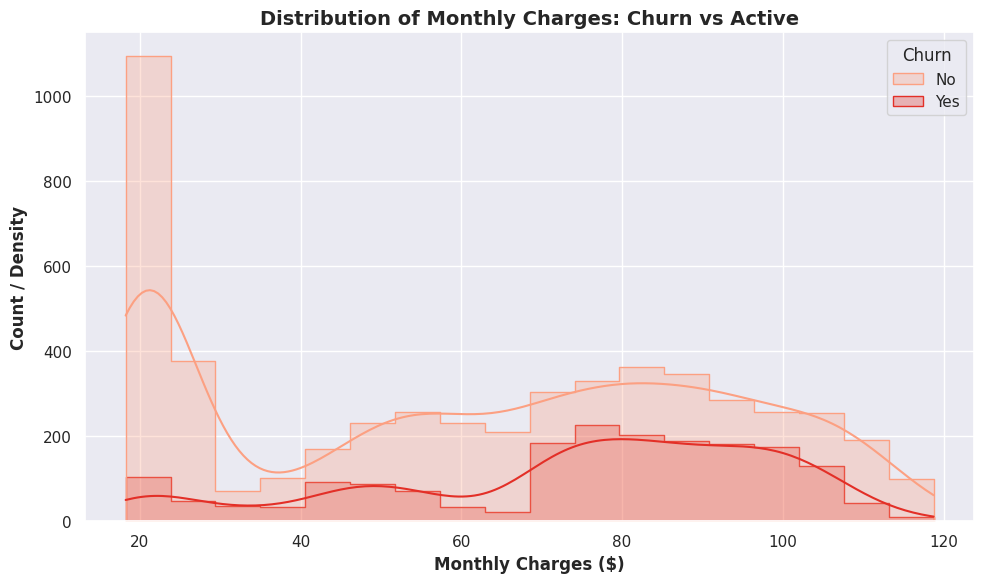

In [ ]:
# Distribution Monthly Charges
churn_mean = df_final[df_final['Churn'] == 'Yes']
nochurn_mean = df_final[df_final['Churn'] == 'No']

churn_revenue = churn_mean['MonthlyCharges'].mean()
nochurn_revenue = nochurn_mean['MonthlyCharges'].mean()

print(f'Rata-rata Revenue dari Pelanggan Churn sebesar ${churn_revenue:,.2f}')
print(f'Rata-rata Revenue dari Pelanggan Aktif sebesar ${nochurn_revenue:,.2f}')

plt.figure(figsize=(10, 6))

sns.histplot(data=df_final, x='MonthlyCharges', hue='Churn',
             kde=True, element='step', palette='Reds',
             alpha=0.3, common_norm=False)

plt.title('Distribution of Monthly Charges: Churn vs Active', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges ($)', fontweight='bold')
plt.ylabel('Count / Density', fontweight='bold')

plt.tight_layout()
plt.show()

### b. Distribution Tenure

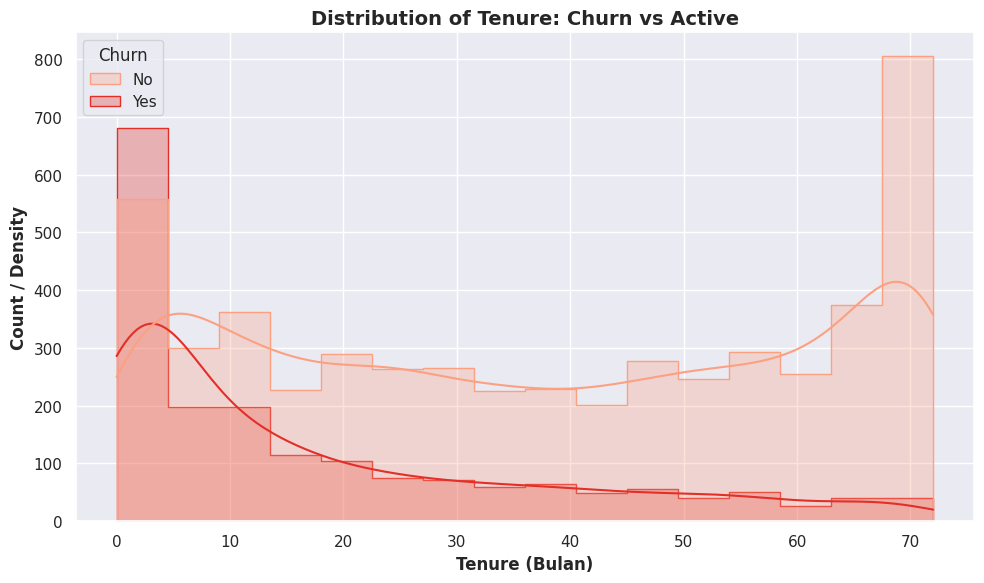

In [ ]:
# Distribution Tenure
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_final,
    x='tenure',
    hue='Churn',
    kde=True,
    element='step',
    palette='Reds',
    alpha=0.3,
    common_norm=False
)

plt.title('Distribution of Tenure: Churn vs Active',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Tenure (Bulan)', fontweight='bold')
plt.ylabel('Count / Density', fontweight='bold')

plt.tight_layout()
plt.show()

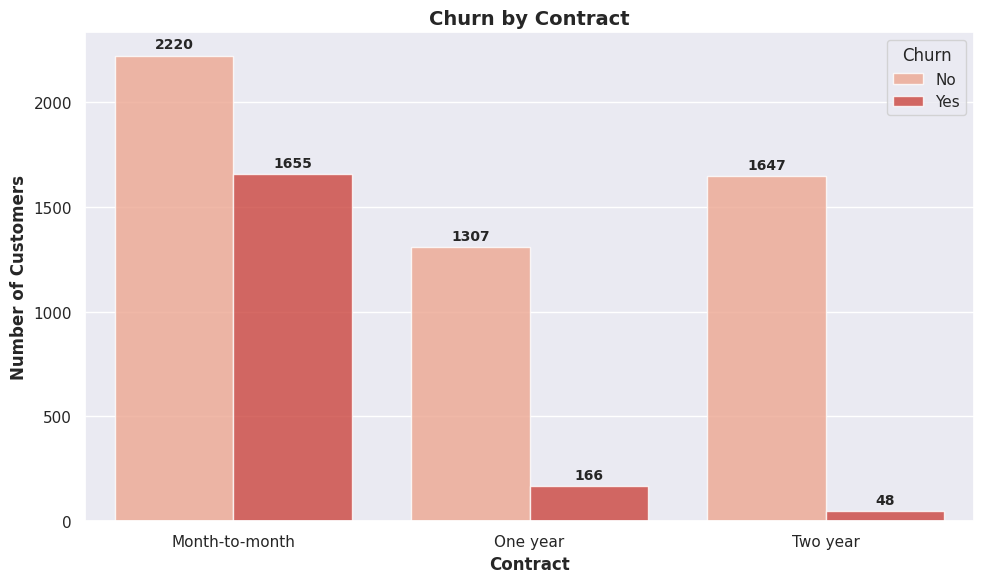

In [ ]:
# Distribution by contract

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_final, x='Contract', hue='Churn', palette='Reds', alpha=0.8)

for i in ax.containers:
    ax.bar_label(i, fontsize=10, fontweight='bold', padding=3)

plt.title('Churn by Contract', fontsize=14, fontweight='bold')
plt.xlabel('Contract', fontweight='bold')
plt.ylabel('Number of Customers', fontweight='bold')

plt.tight_layout()
plt.show()

**Kesimpulan:**

Berdasarkan visualisasi data, pelanggan yang melakukan **churn** cenderung memiliki **biaya bulanan (monthly charges) yang lebih tinggi** dibandingkan pelanggan yang tetap aktif. Selain itu, sebagian besar pelanggan yang churn memiliki **masa berlangganan (tenure) yang relatif singkat**, sedangkan pelanggan dengan tenure yang lebih lama cenderung bertahan menggunakan layanan.

Jenis kontrak juga menunjukkan pengaruh yang signifikan terhadap churn. Pelanggan dengan kontrak **month-to-month** memiliki tingkat churn tertinggi, sementara pelanggan dengan kontrak **satu tahun** dan terutama **dua tahun** memiliki tingkat churn yang jauh lebih rendah. Hal ini menunjukkan bahwa pelanggan baru dengan **biaya bulanan tinggi** dan **kontrak jangka pendek** merupakan kelompok yang paling berisiko melakukan churn.

**Rekomendasi:**

Perusahaan dapat memberikan program onboarding yang lebih baik, menawarkan promo atau diskon untuk beralih ke kontrak jangka panjang, serta memberikan *value* tambahan bagi pelanggan dengan tagihan tinggi

### c. Avg Monthly GB Download

In [ ]:
df_viz = df_final.copy()

# ── 1. Konversi Churn ke binary (0/1) ───────────────────────────────
df_viz['Churn'] = df_viz['Churn'].map({'Yes': 1, 'No': 0}).fillna(
    df_viz['Churn'].apply(
        lambda x: 1 if str(x).strip().lower() in ['yes', '1', 'true'] else 0
    )
).astype(int)

# ── 2. Pastikan MonthlyCharges bertipe numerik ───────────────────────
if 'MonthlyCharges' in df_viz.columns:
    df_viz['MonthlyCharges'] = pd.to_numeric(df_viz['MonthlyCharges'], errors='coerce').fillna(0)

# ── 3. Pastikan Avg Monthly GB Download bertipe numerik ─────────────
if 'Avg Monthly GB Download' in df_viz.columns:
    df_viz['Avg Monthly GB Download'] = pd.to_numeric(
        df_viz['Avg Monthly GB Download'], errors='coerce'
    ).fillna(0)

# ── 4. Pastikan Satisfaction Score bertipe numerik ───────────────────
if 'Satisfaction Score' in df_viz.columns:
    df_viz['Satisfaction Score'] = pd.to_numeric(
        df_viz['Satisfaction Score'], errors='coerce'
    )

# ── 5. Buat kolom RevenueLoss ────────────────────────────────────────
#       RevenueLoss = MonthlyCharges jika churn, 0 jika tidak churn
if 'MonthlyCharges' in df_viz.columns:
    df_viz['RevenueLoss'] = df_viz.apply(
        lambda row: row['MonthlyCharges'] if row['Churn'] == 1 else 0,
        axis=1
    )

# ── 6. Pastikan Offer bertipe string & isi NaN ───────────────────────
if 'Offer' in df_viz.columns:
    df_viz['Offer'] = df_viz['Offer'].fillna('No Offer').astype(str)


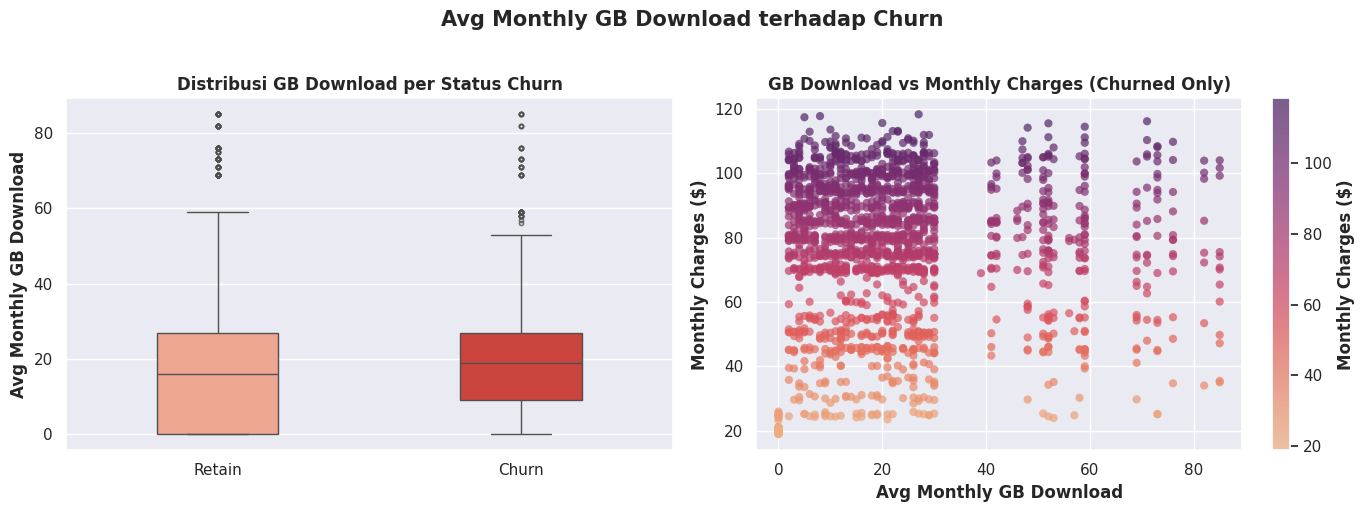


Avg GB Download by Churn:
        count   mean    std  min  25%   50%   75%   max
Churn                                                  
0      5174.0  19.92  21.10  0.0  0.0  16.0  27.0  85.0
1      1869.0  22.18  18.31  0.0  9.0  19.0  27.0  85.0


In [ ]:
# Korelasi Avg Monthly GB Download terhadap churn

if 'Avg Monthly GB Download' in df_viz.columns:

    churned = df_viz[df_viz['Churn'] == 1]  # ← pakai df_viz

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Avg Monthly GB Download terhadap Churn',
                 fontsize=15, fontweight='bold', y=1.02)

    sns.boxplot(
        data=df_viz,                          # ← pakai df_viz
        x='Churn',
        y='Avg Monthly GB Download',
        ax=axes[0],
        width=0.4,
        palette='Reds',
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
    )
    axes[0].set_title('Distribusi GB Download per Status Churn',
                      fontsize=12, fontweight='bold')
    axes[0].set_xticklabels(['Retain', 'Churn'])
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Avg Monthly GB Download', fontweight='bold')

    if 'MonthlyCharges' in df_viz.columns and len(churned) > 0:
        sc = axes[1].scatter(
            churned['Avg Monthly GB Download'],
            churned['MonthlyCharges'],
            c=churned['MonthlyCharges'],
            cmap='flare',
            alpha=0.7,
            edgecolors='none',
            s=35
        )
        cbar = plt.colorbar(sc, ax=axes[1])
        cbar.set_label('Monthly Charges ($)', fontweight='bold')
        axes[1].set_xlabel('Avg Monthly GB Download', fontweight='bold')
        axes[1].set_ylabel('Monthly Charges ($)', fontweight='bold')
        axes[1].set_title('GB Download vs Monthly Charges (Churned Only)',
                          fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print('\nAvg GB Download by Churn:')
    print(df_viz.groupby('Churn')['Avg Monthly GB Download'].describe().round(2))

**HASIL ANALISIS**

Avg Monthly GB Download vs Churn
- Pelanggan yang aktif menggunakan layanan pun tetap churn. Jangan alokasikan anggaran retensi berdasarkan "siapa yang paling sering download" karena ini tidak prediktif. Fokus ke Contract dan Satisfaction yang terbukti lebih akurat.
- Investigasi mengapa pelanggan high-usage tetap churn. Pelanggan yang download banyak dan bayar mahal tapi tetap churn adalah sinyal serius, mereka menggunakan layanan tapi merasa tidak sepadan nilainya. Kemungkinan masalahnya kompetitor menawarkan harga lebih murah untuk kuota yang sama, atau ada masalah kualitas jaringan yang tidak terefleksi di data GB.

## **3. Segmen mana yang menyumbang revenue loss terbesar**

### a. Segmen Produk (internet services)

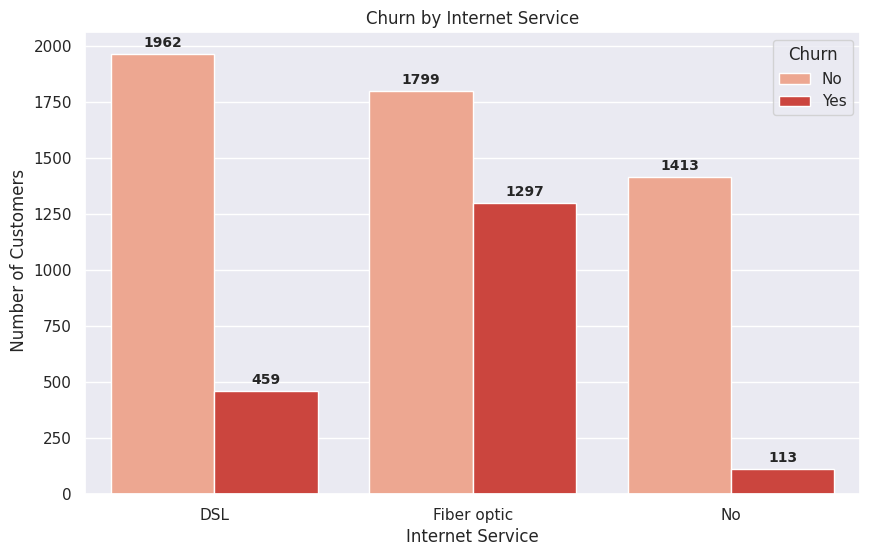

In [ ]:
#Churn by Internet Services
plt.figure(figsize=(10,6))
ax = sns.countplot(data=df_final, x='InternetService', hue='Churn', palette='Reds')


for i in ax.containers:
    ax.bar_label(i, fontsize=10, fontweight='bold', padding=3)

plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel(' Number of Customers')
plt.show()

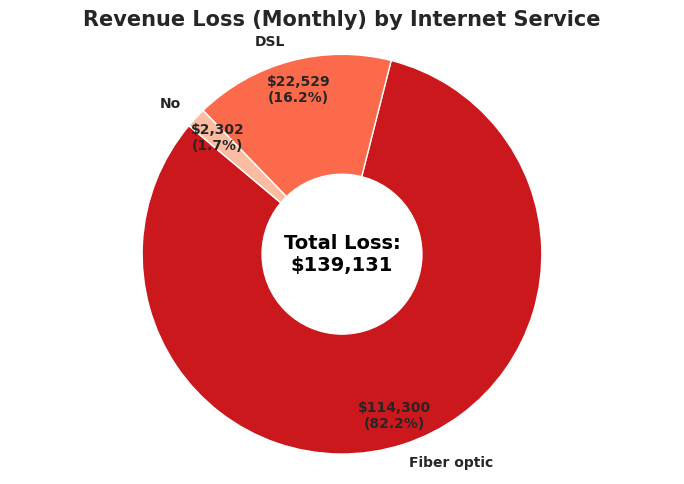

In [ ]:
# Menghitung revenue loss berdasarkan Internet Service
df_churn = df_final[df_final['Churn'] == 'Yes']
revenue_loss_check = df_churn.groupby('InternetService')['MonthlyCharges'].sum().sort_values(ascending=False)
total_loss = revenue_loss_check.sum()

labels = revenue_loss_check.index
sizes = revenue_loss_check.values
plt.figure(figsize=(7, 5))

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = (pct*total/100.0)
        return f'${val:,.0f}\n({pct:.1f}%)'
    return my_autopct

plt.pie(sizes, labels=labels, autopct=make_autopct(sizes), startangle=140,
        colors=sns.color_palette('Reds_r', len(labels)), pctdistance=0.85,
        textprops={'fontweight': 'bold', 'fontsize': 10})

centre_circle = plt.Circle((0,0), 0.40, fc='white')
plt.gcf().gca().add_artist(centre_circle)

plt.text(0, 0, f'Total Loss:\n${total_loss:,.0f}', ha='center', va='center',
         fontweight='bold', fontsize=14, color='black')

plt.title('Revenue Loss (Monthly) by Internet Service', fontweight='bold', fontsize=15)
plt.axis('equal')
plt.tight_layout()
plt.show()

### b. Segmen perilaku bayar (Payment Method)

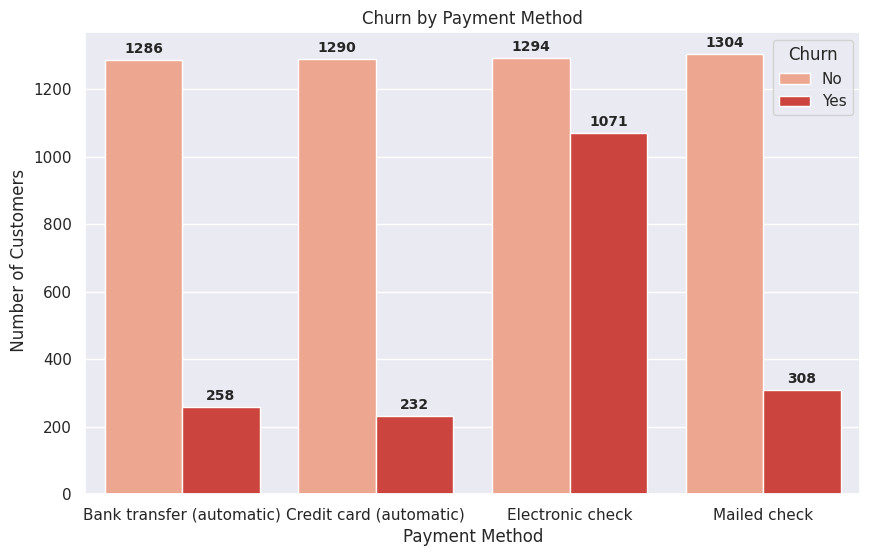

In [ ]:
plt.figure(figsize=(10,6))
ax = sns.countplot(data=df_final, x='PaymentMethod', hue='Churn', palette='Reds')


for i in ax.containers:
    ax.bar_label(i, fontsize=10, fontweight='bold', padding=3)

plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel(' Number of Customers')
plt.show()

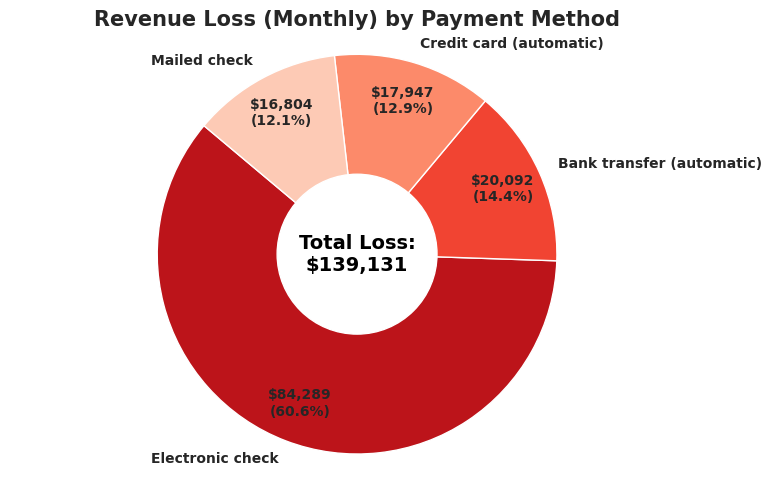

In [ ]:
# Menghitung revenue loss berdasarkan Payment Method
df_churn = df_final[df_final['Churn'] == 'Yes']
revenue_loss_payment = df_churn.groupby('PaymentMethod')['MonthlyCharges'].sum().sort_values(ascending=False)
total_loss = revenue_loss_payment.sum()

labels = revenue_loss_payment.index
sizes = revenue_loss_payment.values
plt.figure(figsize=(8, 5))

make_autopct('values')

plt.pie(sizes, labels=labels, autopct=make_autopct(sizes), startangle=140,
        colors=sns.color_palette('Reds_r', len(labels)), pctdistance=0.80,
        textprops={'fontweight': 'bold', 'fontsize': 10})


centre_circle = plt.Circle((0,0), 0.40, fc='white')
plt.gcf().gca().add_artist(centre_circle)

plt.text(0, 0, f'Total Loss:\n${total_loss:,.0f}', ha='center', va='center',
         fontweight='bold', fontsize=14, color='black')

plt.title('Revenue Loss (Monthly) by Payment Method', fontweight='bold', fontsize=15)
plt.axis('equal')
plt.tight_layout()
plt.show()

**Kesimpulan:**

Pelanggan Fiber Optic merupakan kontributor utama churn. Sebanyak 1.297 pelanggan Fiber Optic melakukan churn, jauh lebih tinggi dibandingkan DSL (459 pelanggan) dan pelanggan tanpa layanan internet (113 pelanggan). Dampaknya terhadap bisnis juga sangat besar, karena segmen Fiber Optic menyumbang $114.300 (82,2%) dari total kehilangan pendapatan bulanan akibat churn sebesar $139.131. Hal ini menunjukkan bahwa meskipun Fiber Optic merupakan layanan dengan nilai pendapatan tinggi, pelanggan pada segmen ini memiliki risiko churn yang jauh lebih besar sehingga perlu menjadi prioritas utama dalam strategi retensi pelanggan.

Metode pembayaran Electronic Check memiliki tingkat churn tertinggi dengan 1.071 pelanggan churn, jauh lebih banyak dibandingkan metode pembayaran lainnya yang berada di kisaran 232–308 pelanggan. Dari sisi finansial, pelanggan yang menggunakan Electronic Check juga menyebabkan kerugian terbesar, yaitu $84.289 (60,6%) dari total kehilangan pendapatan bulanan akibat churn. Temuan ini mengindikasikan bahwa pengguna Electronic Check merupakan segmen pelanggan berisiko tinggi dan perlu dianalisis lebih lanjut untuk mengetahui faktor penyebab churn, seperti kemudahan pembayaran, pengalaman pelanggan, atau karakteristik pelanggan yang memilih metode pembayaran tersebut.

**Rekomendasi:**

Perusahaan sangat disarankan untuk menginvestigasi masalah pada kualitas/harga layanan Fiber Optic serta mengevaluasi pengalaman pengguna (user experience) atau kendala teknis pada sistem pembayaran Electronic Check guna menekan angka kerugian yang lebih besar.

### c. Segmen Konsumen (Demografi)

Profiling Karakteristik.
 - Umur. Kelompok umur mana yang mendominasi basis pelanggan saat ini?
 - Status Keluarga & Tanggungan. Apakah layanan telco ini lebih banyak digunakan oleh individu tunggal (single) atau kelompok keluarga (household)?
 - Gender. Apakah ada dominasi gender tertentu dalam penggunaan layanan?
 - domisili area dan populasi
 - Geografis

 Tambahan.
 - Early warning system berdasarkan satisfaction score

#### (1) Kelompok umur

In [ ]:
# Batasan Umur: Under 30, Productive Age 30-64, Senior Citizen 65+
print(df_final.groupby('Age_Group')['Churn'].value_counts(normalize=True).unstack() * 100)

Churn                          No        Yes
Age_Group                                   
Under 30                78.301213  21.698787
Productive Age (30-64)  75.800000  24.200000
Senior Citizen (65+)    58.318739  41.681261


senior citizen adalah kelompok pelanggan paling mudah churn

In [ ]:
# Menghitung jumlah orang dan persentase tiap kelompok
age_counts = df_final['Age_Group'].value_counts()
age_percentages = df_final['Age_Group'].value_counts(normalize=True) * 100

# Gabungkan ke dalam satu tabel ringkas untuk diintip
tabel_umur = pd.DataFrame({
    'Jumlah Pelanggan': age_counts,
    'Persentase (%)': age_percentages.round(2)
})
print("--- Tabel Distribusi Umur Pelanggan ---")
print(tabel_umur)

--- Tabel Distribusi Umur Pelanggan ---
                        Jumlah Pelanggan  Persentase (%)
Age_Group                                               
Productive Age (30-64)              4500           63.89
Under 30                            1401           19.89
Senior Citizen (65+)                1142           16.21


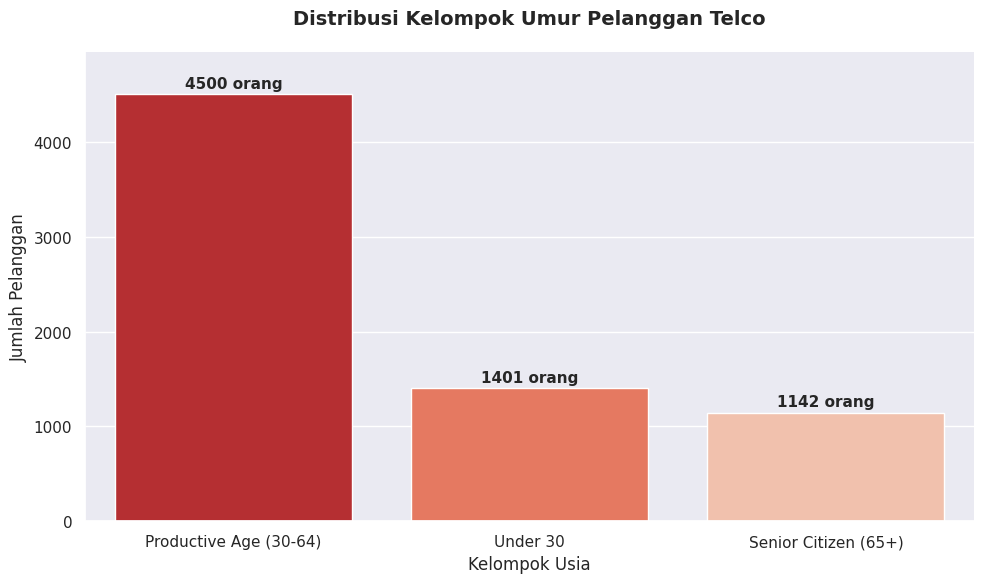

In [ ]:
# VISUALISASI
# urutin data tabel
tabel_umur = tabel_umur.sort_values(by='Jumlah Pelanggan', ascending=False)

# Atur tema grafik agar minimalis dan bersih
plt.figure(figsize=(10, 6))

# Buat Bar Chart
ax = sns.barplot(
    x=tabel_umur.index,
    y=tabel_umur['Jumlah Pelanggan'],
    palette='Reds_r', # Warna gradasi biru yang profesional
    order=tabel_umur.index
)

# Tambahkan label angka di atas setiap batang grafik agar mudah dibaca
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())} orang",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=11, fontweight='bold'
    )

# Rapikan teks dan judul grafik
plt.title('Distribusi Kelompok Umur Pelanggan Telco', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Kelompok Usia', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)
plt.ylim(0, df_final['Age_Group'].value_counts().max() * 1.1) # Beri ruang di atas grafik
sns.despine() # Hapus garis kotak tepi yang tidak perlu

# Tampilkan grafik
plt.tight_layout()
plt.show()

pelanggan di dominasi oleh productive age.

Dominasi Usia Produktif (63,89%): Mayoritas pengguna berada di usia matang dan bekerja. Kelompok ini adalah tulang punggung pendapatan (revenue generator) utama perusahaan karena memiliki daya beli yang stabil dan mandiri.

Potensi Pasar Muda (19,89%): Generasi Under 30 menduduki posisi kedua. Walaupun secara jumlah lebih kecil, kelompok ini krusial untuk pertumbuhan jangka panjang (future market share) karena masa pakai mereka yang masih panjang.

Kelompok Senior (16,21%): Lansia memiliki porsi terkecil namun tetap signifikan (lebih dari 1.000 pelanggan). Kelompok ini biasanya lebih sensitif terhadap kemudahan penggunaan aplikasi/layanan dan kualitas customer service.

--- Persentase Churn per Kelompok Usia (%) ---
Churn                      No    Yes
Age_Group                           
Under 30                78.30  21.70
Productive Age (30-64)  75.80  24.20
Senior Citizen (65+)    58.32  41.68


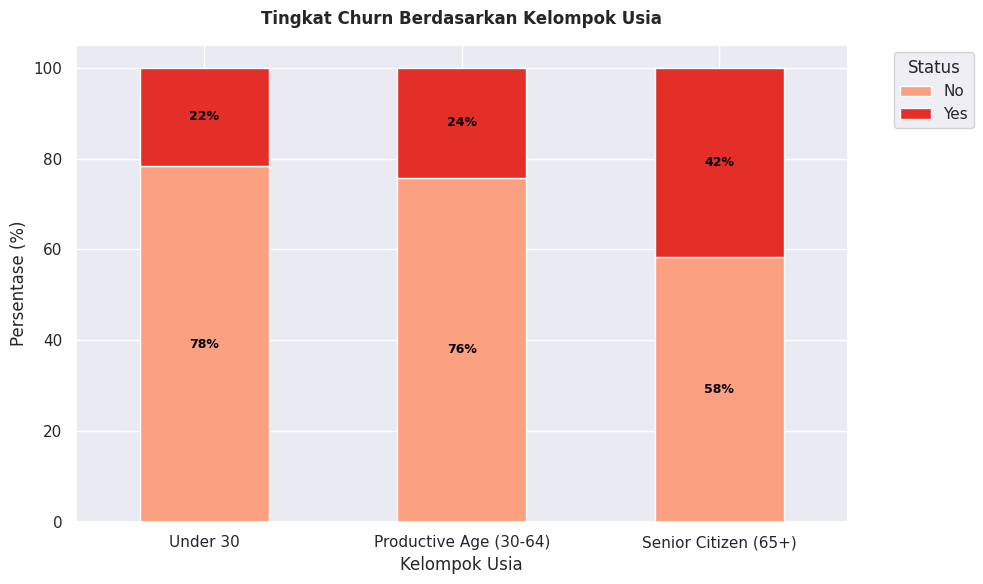

In [ ]:
# PERSENTASE CHURN PER KELOMPOK USIA
# ==========================================

# Membuat tabel silang antara Kelompok Umur dan Churn (dalam persentase baris)
churn_umur = pd.crosstab(df_final['Age_Group'], df_final['Churn'], normalize='index') * 100
print("--- Persentase Churn per Kelompok Usia (%) ---")
print(churn_umur.round(2))


# Visualisasi Bar Chart Bertumpuk (Stacked Bar Chart) untuk PPT
plt.figure(figsize=(10, 6))
ax=churn_umur.plot(kind='bar', stacked=True, color=sns.color_palette('Reds', 2), ax=plt.gca())

for container in ax.containers:
    labels = [
        f'{v:,.0f}%' if v > 0 else ''
        for v in container.datavalues
        ]
    ax.bar_label(
        container, labels=labels, label_type='center',
        fontsize=9, color='black', fontweight='bold'
        )

plt.title('Tingkat Churn Berdasarkan Kelompok Usia', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Kelompok Usia')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

terlihat tren linear di mana risiko pelanggan untuk berhenti berlangganan semakin meningkat seiring bertambahnya usia. Kelompok **Senior Citizen (65+)** menjadi kelompok yang paling rentan kabur dengan tingkat churn yang sangat tinggi mencapai **41,68%**, hampir dua kali lipat dibandingkan kelompok **Under 30 (21,70%)** dan **Productive Age (24,20%)**. Hasil ini mengindikasikan adanya masalah kritis pada retensi pelanggan lansia, yang kemungkinan besar dipicu oleh ketidakcocokan produk, kendala adaptasi teknologi, atau kebutuhan paket khusus yang lebih ramah bagi senior yang belum terpenuhi oleh perusahaan saat ini.

#### (2) Status keluarga & tanggungan


=== Jumlah Customer Profil ===

Customer_Profile
Household (Keluarga)         3763
Single (Individu Tunggal)    3280
Name: count, dtype: int64
n--- Persentase Churn per Profil Keluarga (%) ---
Churn                         No    Yes
Customer_Profile                       
Household (Keluarga)       80.18  19.82
Single (Individu Tunggal)  65.76  34.24


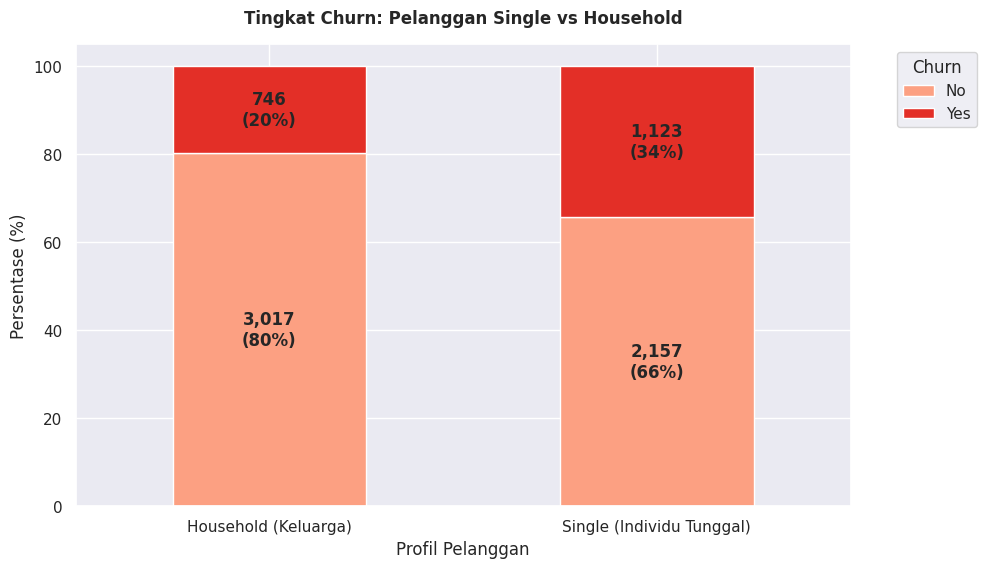

In [ ]:
# manggil jumlah customer profil
print("\n=== Jumlah Customer Profil ===\n")
print(df_final['Customer_Profile'].value_counts())

# PERSENTASE CHURN PER PROFIL KELUARGA

# Membuat tabel silang antara Profil Keluarga dan Churn (absoulte counts)
churn_counts = pd.crosstab(df_final['Customer_Profile'], df_final['Churn'])

# Membuat tabel silang antara Profil Keluarga dan Churn (dalam persentase)
churn_profil = churn_counts.div(churn_counts.sum(axis=1), axis=0) * 100

print("n--- Persentase Churn per Profil Keluarga (%) ---")
print(churn_profil.round(2))

# Visualisasi
plt.figure(figsize=(10, 6))
ax=churn_profil.plot(kind='bar', stacked=True, color=sns.color_palette('Reds', 2), ax=plt.gca())

# Add labels to the bars with both count and percentage
for churn_status_idx, container in enumerate(ax.containers):
    for i, bar in enumerate(container):
        percentage = bar.get_height()
        customer_profile = churn_profil.index[i]
        churn_category = churn_profil.columns[churn_status_idx]
        count = churn_counts.loc[customer_profile, churn_category]

        if percentage > 0:
            ax.annotate(
                f'{int(count):,}\n({percentage:,.0f}%)',
                (bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2),
                ha='center', va='center', fontweight='bold'
            )

plt.title('Tingkat Churn: Pelanggan Single vs Household', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Profil Pelanggan')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Segmentasi berdasarkan struktur sosial menunjukkan bahwa status hubungan dan tanggung jawab keluarga memiliki pengaruh yang sangat kuat terhadap loyalitas pelanggan. Pelanggan dengan profil **Single (Individu Tunggal)** menunjukkan tingkat churn yang signifikan yaitu sebesar **34,24%**, jauh lebih tinggi dibandingkan kelompok **Household (Keluarga)** yang hanya sebesar **19,82%**.

Pelanggan yang sudah berkeluarga atau memiliki tanggungan memiliki kecenderungan *switching cost* (biaya dan kerepotan untuk pindah provider) yang lebih tinggi karena proses migrasi layanan interet/telekomunikasi satu rumah jauh lebih rumit, sedangkan pelanggan *single* jauh lebih fleksibel untuk berpindah demi mencari promo yang lebih murah di pasar.

#### (3) Gender

--- Tabel Keseimbangan Gender ---
        Jumlah Pelanggan  Persentase (%)
gender                                  
Male                3555           50.48
Female              3488           49.52

--- Persentase Churn per Gender (%) ---
Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16


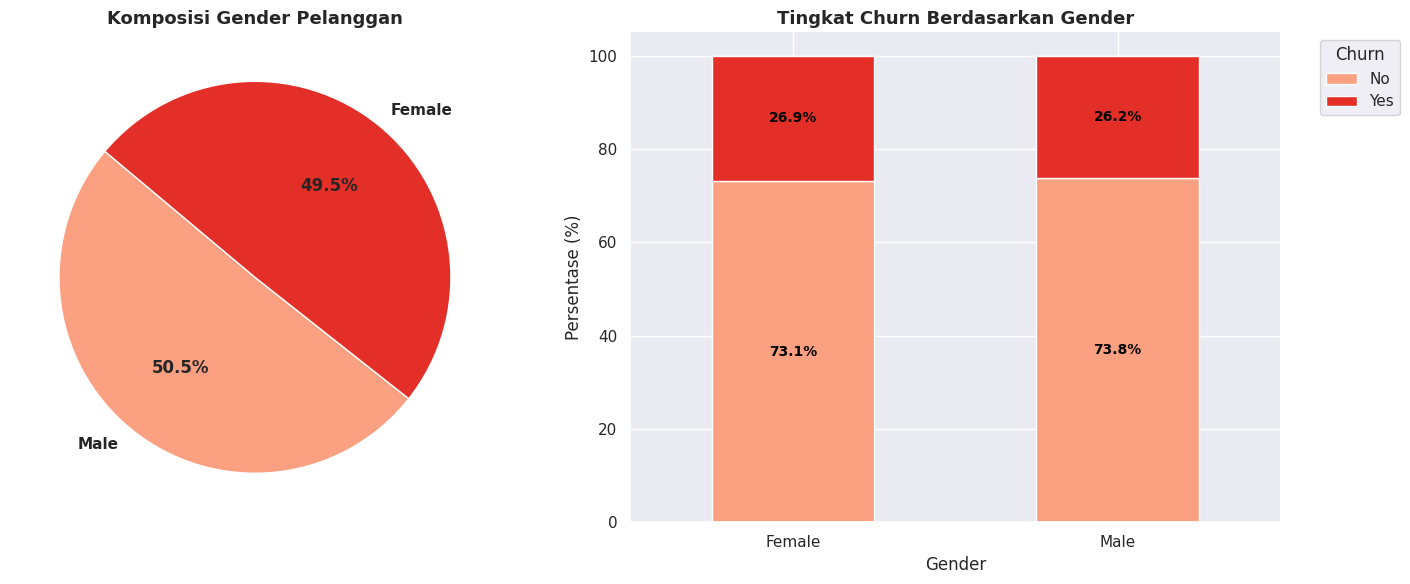

In [ ]:
# ==========================================
# 1. MENGHITUNG STATISTIK DESKRIPTIF GENDER
# ==========================================
gender_counts = df_final['gender'].value_counts()
gender_percentages = df_final['gender'].value_counts(normalize=True) * 100

# Gabungkan ke dalam tabel ringkas
tabel_gender = pd.DataFrame({
    'Jumlah Pelanggan': gender_counts,
    'Persentase (%)': gender_percentages.round(2)
})
print("--- Tabel Keseimbangan Gender ---")
print(tabel_gender)

# ==========================================
# 2. PERSENTASE CHURN PER GENDER
# ==========================================
# Membuat tabel silang antara Gender dan Churn
churn_gender = pd.crosstab(df_final['gender'], df_final['Churn'], normalize='index') * 100
print("\n--- Persentase Churn per Gender (%) ---")
print(churn_gender.round(2))

# ==========================================
# 3. VISUALISASI GENDER ANALYSIS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Grafik 1: Komposisi Gender (Pie Chart)
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('Reds', 2),
            textprops={'fontweight': 'bold'})
axes[0].set_title('Komposisi Gender Pelanggan', fontsize=13, fontweight='bold')

# Grafik 2: Tingkat Churn per Gender (Stacked Bar Chart)
churn_gender.plot(kind='bar', stacked=True, color=sns.color_palette('Reds', 2), ax=axes[1])
axes[1].set_title('Tingkat Churn Berdasarkan Gender', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Persentase (%)')
axes[1].set_xlabel('Gender')
axes[1].legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')

# Tambahkan label persentase di bar chart
for container in axes[1].containers:
    labels = [f'{v:,.1f}%' if v > 0 else '' for v in container.datavalues]
    axes[1].bar_label(container, labels=labels, label_type='center',
                      fontsize=10, color='black', fontweight='bold')

plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

faktor gender tidak memiliki pengaruh yang signifikan terhadap keputusan pelanggan untuk berhenti menggunakan layanan. Tingkat churn untuk kelompok **Female berada di angka 26,92%** dan kelompok **Male berada di angka 26,16%**, dengan selisih yang sangat tipis. Hal ini membuktikan bahwa perilaku *churn* di perusahaan Telco ini murni didorong oleh faktor eksternal seperti kualitas layanan, harga, produk, atau pengalaman pelanggan, dan bukan karena adanya bias kecenderungan perilaku dari salah satu gender tertentu.

#### (4) Geografis

##### 1. Population

--- Tabel Persentase Churn Berdasarkan Kepadatan Wilayah (%) ---
Churn                               No    Yes
Area_Type                                    
Rural (Pedesaan/Kota Kecil)      75.33  24.67
Suburban (Pinggiran Kota)        75.67  24.33
Urban (Metropolitan/Kota Besar)  69.38  30.62


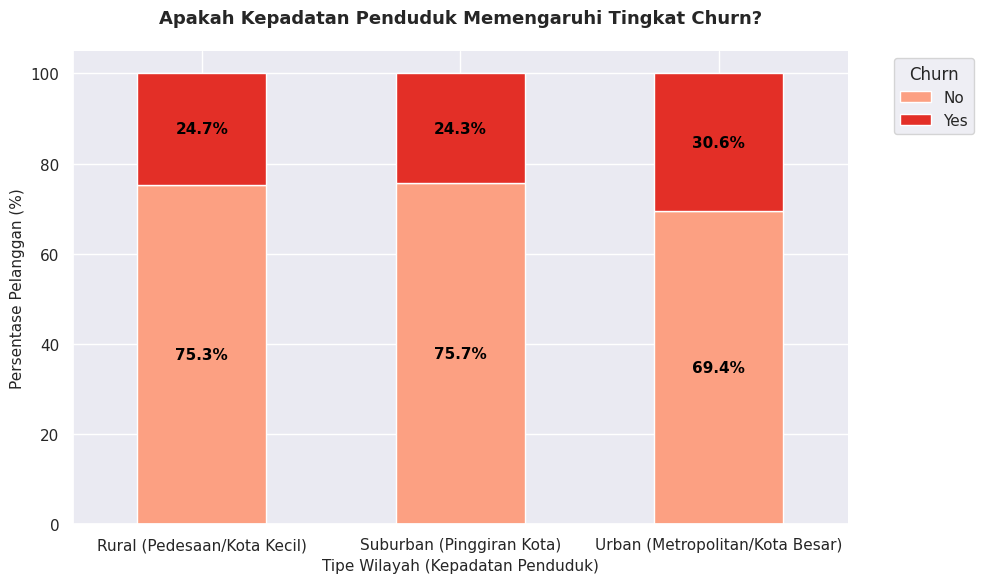

In [ ]:
# MENGHITUNG PERSENTASE CHURN PER WILAYAH
# Membuat tabel silang antara Area Type dan Churn (persentase berdasarkan baris)
churn_wilayah = pd.crosstab(df_final['Area_Type'], df_final['Churn'], normalize='index') * 100

print("--- Tabel Persentase Churn Berdasarkan Kepadatan Wilayah (%) ---")
print(churn_wilayah.round(2))

# VISUALISASI
plt.figure(figsize=(10, 6))

# Membuat Stacked Bar Chart
ax = churn_wilayah.plot(
    kind='bar',
    stacked=True,
    color=sns.color_palette('Reds', 2),
    ax=plt.gca()
)

# Menambahkan label persentase di dalam batang grafik agar bersih
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 5: # Hanya tampilkan label jika persentasenya cukup besar biar ga tumpang tindih
        ax.annotate(
            f'{height:.1f}%',
            (x + width/2, y + height/2),
            ha='center', va='center',
            color='black', fontweight='bold', fontsize=11
        )

# Merapikan tampilan grafik sesuai prinsip satu slide satu pesan
plt.title('Apakah Kepadatan Penduduk Memengaruhi Tingkat Churn?', fontsize=13, fontweight='bold', pad=20)
plt.xlabel('Tipe Wilayah (Kepadatan Penduduk)', fontsize=11)
plt.ylabel('Persentase Pelanggan (%)', fontsize=11)
plt.xticks(rotation=0) # Memastikan teks wilayah mendatar (tidak miring) agar mudah dibaca
plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()

plt.tight_layout()
plt.show()

tingkat *churn* tertinggi berada di wilayah **Urban (Metropolitan/Kota Besar) dengan angka mencapai 30,62%**, sedangkan wilayah **Rural (24,67%)** dan **Suburban (24,33%)**.

tingginya angka kehilangan pelanggan di area metropolitan ini sangat wajar terjadi karena ketatnya penetrasi pasar dan banyaknya pilihan provider kompetitor yang agresif menawarkan perang harga. Sebaliknya, pelanggan di area pedesaan jauh lebih loyal karena keterbatasan opsi infrastruktur provider lain di wilayah mereka (*switching cost* cenderung tinggi).

##### 2. Cities

In [ ]:
# ========================================================
# 1. FILTER DATA PELANGGAN YANG CHURN & CARI TOP 5 KOTA
# ========================================================
df_churn = df_final[df_final['Churn'] == 'Yes']

# Cari 5 kota dengan jumlah baris churn terbanyak
top_5_cities = df_churn['City'].value_counts().head(5).index.tolist()


# ========================================================
# 2. BEDAH CHURN REASON DI KOTA-KOTA TOP TERSEBUT
# ========================================================
# Filter data churn hanya untuk 5 kota terbesar ini
df_top_cities_churn = df_churn[df_churn['City'].isin(top_5_cities)]

# Membuat tabel silang untuk melihat alasan churn per kota
tabel_alasan_kota = pd.crosstab(
    df_top_cities_churn['City'],
    df_top_cities_churn['Churn Reason']
)

print("--- 5 Kota dengan Jumlah Churn Tertinggi ---")
print(df_churn['City'].value_counts().head(5))

print("\n--- Distribusi Alasan Churn di Top 5 Kota ---")
# Menampilkan 3 alasan teratas saja per kota agar tidak banjir teks
for kota in top_5_cities:
    print(f"\n📍 Kota: {kota}")
    alasan_top = df_top_cities_churn[df_top_cities_churn['City'] == kota]['Churn Reason'].value_counts().head(3)
    print(alasan_top)

--- 5 Kota dengan Jumlah Churn Tertinggi ---
City
San Diego        185
Los Angeles       78
San Francisco     31
San Jose          29
Sacramento        26
Name: count, dtype: int64

--- Distribusi Alasan Churn di Top 5 Kota ---

📍 Kota: San Diego
Churn Reason
Competitor made better offer    146
Don't know                       15
Attitude of support person        8
Name: count, dtype: int64

📍 Kota: Los Angeles
Churn Reason
Competitor had better devices                15
Competitor offered higher download speeds     9
Competitor offered more data                  8
Name: count, dtype: int64

📍 Kota: San Francisco
Churn Reason
Competitor had better devices                6
Competitor offered more data                 4
Competitor offered higher download speeds    4
Name: count, dtype: int64

📍 Kota: San Jose
Churn Reason
Competitor had better devices                7
Competitor offered more data                 4
Competitor offered higher download speeds    3
Name: count, dtype: int64



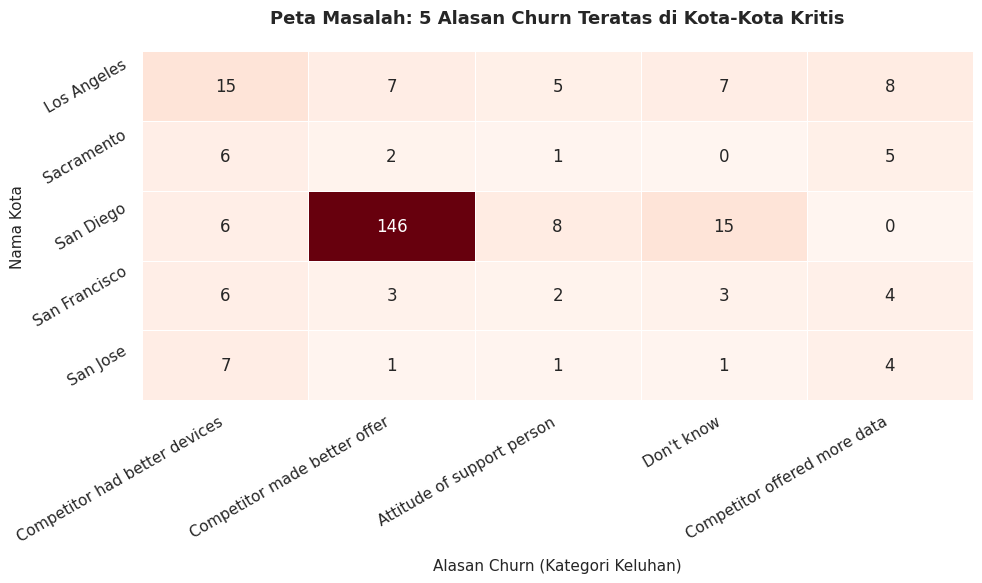

In [ ]:
# ========================================================
# 3. VISUALISASI HEATMAP
# ========================================================
# Kita ambil 5 alasan churn paling populer secara umum untuk dijadikan grafik
top_5_reasons = df_churn['Churn Reason'].value_counts().head(5).index

# Buat matriks khusus untuk heatmap
matrix_heatmap = pd.crosstab(
    df_top_cities_churn['City'],
    df_top_cities_churn['Churn Reason']
)[top_5_reasons]

plt.figure(figsize=(10, 6))
# Menggunakan heatmap dengan warna merah/oranye untuk indikasi masalah (risiko)
sns.heatmap(matrix_heatmap, annot=True, fmt='d', cmap='Reds', cbar=False, linewidths=0.5)

plt.title('Peta Masalah: 5 Alasan Churn Teratas di Kota-Kota Kritis', fontsize=13, fontweight='bold', pad=20)
plt.xlabel('Alasan Churn (Kategori Keluhan)', fontsize=11, labelpad=10)
plt.ylabel('Nama Kota', fontsize=11)
plt.yticks(rotation=30, ha='right')
plt.xticks(rotation=30, ha='right') # Memiringkan teks alasan agar muat dan rapi
plt.tight_layout()
plt.show()

tingkat kehilangan pelanggan tertinggi berpusat di **San Diego (185 pelanggan)** dan **Los Angeles (78 pelanggan)**.

Menariknya, motif perpindahan pelanggan (*churn reason*) di kota-kota kritis ini didominasi oleh faktor eksternal berupa agresivitas kompetitor, namun dengan strategi yang berbeda di setiap lokalitas. Di **San Diego dan Fallbrook**, alasan utama pelanggan kabur adalah karena kompetitor memberikan penawaran harga/paket yang jauh lebih menarik (*Competitor made better offer*). Sementara itu, di wilayah metropolitan lainnya seperti **Los Angeles, San Francisco, dan San Jose**, kompetitor berhasil merebut pelanggan bukan lewat perang harga, melainkan lewat keunggulan fasilitas seperti penyediaan perangkat yang lebih canggih (*better devices*) serta kecepatan unduh yang lebih tinggi (*higher download speeds*).

#### (5) Early warning system berdasarkan satisfaction score

In [ ]:
# ========================================================
# 1. HITUNG JUMLAH & PERSENTASE CHURN PER SATISFACTION SCORE
# ========================================================
# Menghitung jumlah mutlak (orang)
tabel_jumlah = pd.crosstab(df_final['Satisfaction Score'], df_final['Churn'])

# Menghitung persentase berdasarkan baris (skor)
tabel_persen = pd.crosstab(df_final['Satisfaction Score'], df_final['Churn'], normalize='index') * 100

print("=== JUMLAH PELANGGAN (CHURN VS NO) PER SKOR KEPUASAN ===")
print(tabel_jumlah)

print("\n=== PERSENTASE CHURN PER SKOR KEPUASAN (%) ===")
print(tabel_persen.round(2))

=== JUMLAH PELANGGAN (CHURN VS NO) PER SKOR KEPUASAN ===
Churn                 No  Yes
Satisfaction Score           
1                      0  922
2                      0  518
3                   2236  429
4                   1789    0
5                   1149    0

=== PERSENTASE CHURN PER SKOR KEPUASAN (%) ===
Churn                  No    Yes
Satisfaction Score              
1                     0.0  100.0
2                     0.0  100.0
3                    83.9   16.1
4                   100.0    0.0
5                   100.0    0.0


- Skor 1 dan 2: 100% pasti Churn (total 1.440 orang kabur). Tidak ada satu pun yang bertahan (No = 0).
- Skor 4 dan 5: 100\% pasti Bertahan (total 2.938 orang setia). Tidak ada satu pun yang kabur (Yes = 0).

artinya, penentunya ada di Skor 3 (Area Abu-abu / Swing Voters).
Sebanyak 429 orang sudah terlanjur kabur, tapi ada 2.236 orang yang saat ini masih aktif tapi posisinya kritis (berada di ambang pintu keluar).Kita tidak perlu menyelamatkan skor 1 dan 2 karena mereka sudah terlanjur pindah provider.

Target Early Warning System : Menyelamatkan 2.236 pelanggan aktif yang berada di Skor 3!

=== PROFILING PELANGGAN AKTIF DI SKOR 3 (TOTAL: 2.236 ORANG) ===

1. Distribusi Kelompok Usia:
                        Jumlah  Persentase (%)
Age_Group                                     
Productive Age (30-64)    1483           66.32
Under 30                   468           20.93
Senior Citizen (65+)       285           12.75

2. Distribusi Profil Keluarga:
                           Jumlah  Persentase (%)
Customer_Profile                                 
Household (Keluarga)         1373            61.4
Single (Individu Tunggal)     863            38.6


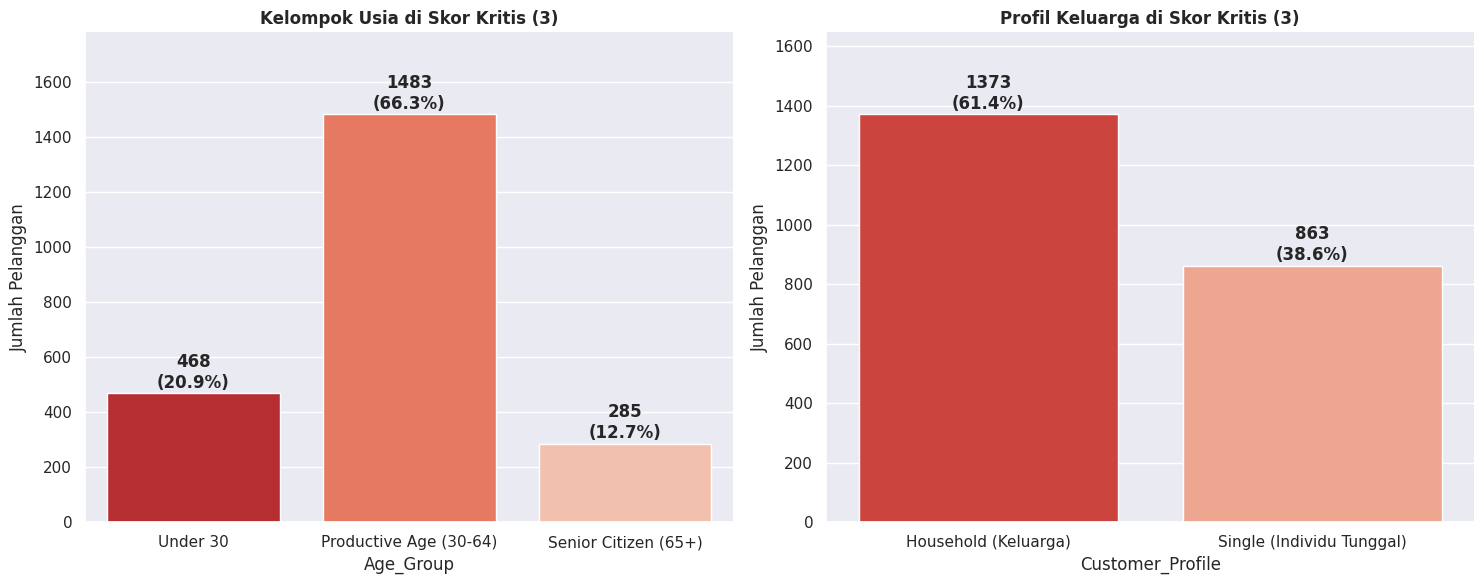

In [ ]:
# ========================================================
# 1. FILTER: PELANGGAN AKTIF YANG BERADA DI SKOR KEPOLISAN 3
# ========================================================
df_kritis = df_final[(df_final['Churn'] == 'No') & (df_final['Satisfaction Score'] == 3)]

# ========================================================
# 2. BEDAH BERDASARKAN KELOMPOK USIA & PROFIL KELUARGA
# ========================================================
print("=== PROFILING PELANGGAN AKTIF DI SKOR 3 (TOTAL: 2.236 ORANG) ===")

print("\n1. Distribusi Kelompok Usia:")
usia_kritis = df_kritis['Age_Group'].value_counts()
usia_kritis_pct = df_kritis['Age_Group'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Jumlah': usia_kritis, 'Persentase (%)': usia_kritis_pct.round(2)}))

print("\n2. Distribusi Profil Keluarga:")
keluarga_kritis = df_kritis['Customer_Profile'].value_counts()
keluarga_kritis_pct = df_kritis['Customer_Profile'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Jumlah': keluarga_kritis, 'Persentase (%)': keluarga_kritis_pct.round(2)}))

# ========================================================
# 3. VISUALISASI SUBPLOT DENGAN PERSENTASE
# ========================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Grafik 1: Kelompok Usia
sns.barplot(x=usia_kritis.index, y=usia_kritis.values, ax=axes[0], palette='Reds_r')
axes[0].set_title('Kelompok Usia di Skor Kritis (3)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')

# Tambahkan label angka dan persentase
for p in axes[0].patches:
    height = p.get_height()
    pct = (height / usia_kritis.sum()) * 100
    axes[0].annotate(f"{int(height)}\n({pct:.1f}%)",
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='center',
                     xytext=(0, 15),
                     textcoords='offset points',
                     fontweight='bold')

# Grafik 2: Profil Keluarga
sns.barplot(x=keluarga_kritis.index, y=keluarga_kritis.values, ax=axes[1], palette='Reds_r')
axes[1].set_title('Profil Keluarga di Skor Kritis (3)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Pelanggan')

# Tambahkan label angka dan persentase
for p in axes[1].patches:
    height = p.get_height()
    pct = (height / keluarga_kritis.sum()) * 100
    axes[1].annotate(f"{int(height)}\n({pct:.1f}%)",
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='center',
                     xytext=(0, 15),
                     textcoords='offset points',
                     fontweight='bold')

# Beri sedikit ruang lebih di atas bar untuk label
axes[0].set_ylim(0, usia_kritis.max() * 1.2)
axes[1].set_ylim(0, keluarga_kritis.max() * 1.2)

sns.despine()
plt.tight_layout()
plt.show()

- Kelompok Usia pada Pelanggan Kritis (Skor 3)

Fakta bahwa usia produktif mendominasi kelompok rentan ini menjadi sinyal peringatan serius bagi perusahaan. Kelompok usia ini merupakan kontributor utama pendapatan perusahaan (*high-value customer*) yang memiliki ekspektasi tinggi terhadap stabilitas jaringan dan efisiensi biaya karena digunakan untuk kebutuhan kerja maupun harian. Jika kelompok produktif yang sedang berada di "ambang pintu keluar" ini tidak segera ditangani, perusahaan berisiko kehilangan tulang punggung pendapatan bisnisnya dalam waktu dekat.

-  Profil Keluarga pada Pelanggan Kritis (Skor 3)

berkebalikan dengan data *historic churn* sebelumnya (di mana pelanggan *single* lebih dominan kabur). Angka 61,40% ini menunjukkan bahwa pelanggan yang sudah berkeluarga saat ini sedang menahan rasa kecewa mereka dan memilih bertahan sementara waktu hanya karena repotnya proses bermigrasi provider satu rumah. Namun, ikatan loyalitas ini sudah sangat rapuh; jika kualitas layanan tidak segera diperbaiki, momentum kejenuhan mereka akan pecah dan berujung pada migrasi massal seluruh anggota keluarga (*household churn*) yang dampaknya jauh lebih merusak bagi stabilitas profit perusahaan.

## **4. Berapa banyak pelanggan high-value yang churn**

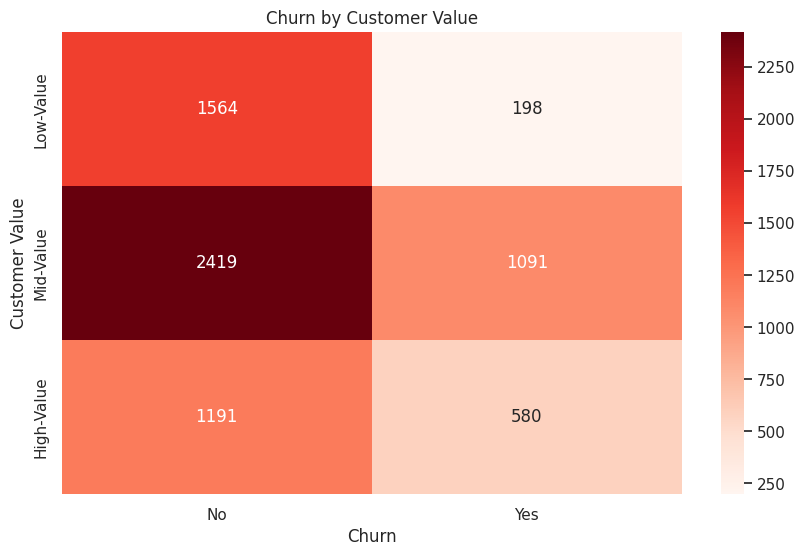

In [ ]:
ct = pd.crosstab(
    df_final['Customer_Value_Segment'],
    df_final['Churn']
)

plt.figure(figsize=(10,6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Reds')

plt.title('Churn by Customer Value')
plt.ylabel('Customer Value')
plt.xlabel('Churn')
plt.show()

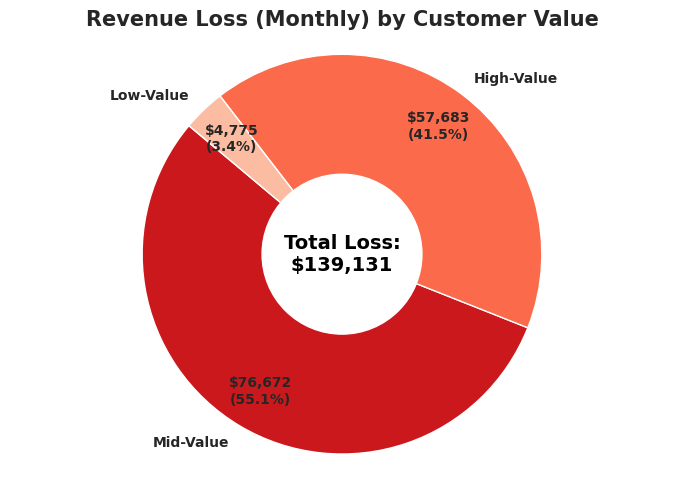

In [ ]:
# Menghitung revenue loss berdasarkan Customer Value
revenue_loss_cust_value = df_churn.groupby('Customer_Value_Segment')['MonthlyCharges'].sum().sort_values(ascending=False)
total_loss = revenue_loss_cust_value.sum()

labels = revenue_loss_cust_value.index
sizes = revenue_loss_cust_value.values
plt.figure(figsize=(7, 5))

make_autopct('values')

plt.pie(sizes, labels=labels, autopct=make_autopct(sizes), startangle=140,
        colors=sns.color_palette('Reds_r', len(labels)), pctdistance=0.80,
        textprops={'fontweight': 'bold', 'fontsize': 10})


centre_circle = plt.Circle((0,0), 0.40, fc='white')
plt.gcf().gca().add_artist(centre_circle)

plt.text(0, 0, f'Total Loss:\n${total_loss:,.0f}', ha='center', va='center',
         fontweight='bold', fontsize=14, color='black')

plt.title('Revenue Loss (Monthly) by Customer Value', fontweight='bold', fontsize=15)
plt.axis('equal')
plt.tight_layout()
plt.show()

**Kesimpulan:**

Dari chart tersebut, ditemukan bahwa segmen Mid-Value memiliki jumlah pelanggan churn terbanyak dengan angka 1.091, serta menyumbang kerugian pendapatan bulanan terbesar sebesar $76.672 (55,1%) dari total revenue loss.

Sementara segmen High-Value, meskipun jumlah churn lebih sedikit (580) dibanding Mid-Value, tetap memberikan dampak finansial yang sangat signifikan dengan kerugian mencapai $57.683 (41,5%). Artinya, ini menunjukkan bahwa kehilangan pelanggan bernilai tinggi dapat menyebabkan penurunan revenue yang besar walaupun jumlahnya tidak sebanyak segmen lain.

**Rekomendasi:**

Perusahaan fokus memprioritaskan strategi retensi pada pelanggan Mid-Value dan High-Value, karena kedua segmen tersebut menyumbang sekitar 96,6% dari total kehilangan pendapatan bulanan. Dengan berfokus pada kedua segmen ini, perusahaan berpotensi mengurangi kerugian pendapatan secara signifikan dan meningkatkan nilai pelanggan dalam jangka panjang.

### Mencari Target Prioritas Utama Cust Curn

In [ ]:
# 1. ambil pelanggan yang MASIH AKTIF (Churn == 'No')
df_aktif = df_final[df_final['Churn'] == 'No']

# 2. Definisikan kondisi filter
kondisi_target_utama = (
    (df_aktif['Customer_Value_Segment'].isin(['High-Value', 'Mid-Value'])) &    # High_Value & Mid_Value
    (df_aktif['Satisfaction Score'].isin([3])) &                          # Satisfaction Score 3
    (df_aktif['InternetService'] == 'Fiber optic')                              # Fiber Optic
)

# 3. Terapkan filter ke dalam dataframe baru
df_target_prioritas_utama = df_aktif[kondisi_target_utama]

# 4. Hitung metrik evaluasi untuk bahan laporan ke mentor
jumlah_user_kritis = df_target_prioritas_utama.shape[0]
total_revenue_terancam = df_target_prioritas_utama['TotalCharges'].sum()
total_cltv_terancam = df_target_prioritas_utama['CLTV'].sum()

print("===========================================")
print("         TARGET PRIORITAS UTAMA            ")
print("===========================================")
print(f"Jumlah Pelanggan Kritis             : {jumlah_user_kritis} User")
print(f"Total Nilai Historis (TotalCharges) : ${total_revenue_terancam:,.2f}")
print(f"Total Potensi Jangka Panjang (CLTV) : ${total_cltv_terancam:,.2f}")
print("==================================================================")

# 5. Intip 5 data teratas untuk memastikan filter sudah bekerja dengan benar
df_target_prioritas_utama[['Customer_Value_Segment', 'Satisfaction Score', 'InternetService', 'TotalCharges', 'CLTV']].head()

         TARGET PRIORITAS UTAMA            
Jumlah Pelanggan Kritis             : 811 User
Total Nilai Historis (TotalCharges) : $3,458,807.90
Total Potensi Jangka Panjang (CLTV) : $3,764,805.00


,Customer_Value_Segment,Satisfaction Score,InternetService,TotalCharges,CLTV
12,High-Value,3,Fiber optic,5681.10,6432
14,High-Value,3,Fiber optic,2686.05,5822
17,High-Value,3,Fiber optic,7382.25,4479
19,High-Value,3,Fiber optic,1862.90,5982
37,Mid-Value,3,Fiber optic,3548.30,3395


kita mengerucutkan target pencegahan. Ditemukan sebanyak **811 pelanggan aktif** yang masuk ke dalam kategori **"Target Kritis Prioritas Utama"**.

Kelompok ini adalah para pelanggan bernilai tinggi (High-Value & Mid-Value) yang menggunakan layanan internet Fiber Optic, namun saat ini sedang berada di fase sangat rentan untuk kabur karena memiliki skor kepuasan yang rendah (Satisfaction Score 3).

Secara finansial, 811 user ini adalah aset yang sangat berharga. Pendapatan historis yang sudah mereka berikan (*TotalCharges*) mencapai **\$3,458,807.90**. Lebih krusial lagi, total potensi nilai ekonomi jangka panjang (*CLTV*) yang melekat pada kelompok ini menyentuh angka **$3,764,805.00**.

Angka ini menegaskan bahwa tim Customer Relations tidak perlu membuang anggaran retensi secara boros ke seluruh pelanggan aktif. Cukup fokus memberikan tindakan penyelamatan langsung ke 811 user prioritas ini, maka perusahaan sedang melindungi potensi pendapatan masa depan sebesar **$3,76 Juta** agar tidak bocor ke kompetitor.

## **5. Berapa kontribusi revenue yang hilang dari jenis layanan tertentu**

### a. Seluruh Revenue Loss

In [ ]:
# Total seluruh revenue loss sebagai pembagi persentase
total_loss_all = df_churn['TotalCharges'].sum()

print(f"TOTAL REVENUE LOSS KESELURUHAN: ${total_loss_all:,.2f}\n")
print("=== KONTRIBUSI REVENUE LOSS PER JENIS LAYANAN ===")

# ========================================================
# 2. HITUNG LOSS BERDASARKAN LAYANAN INTERNET UTAMA
# ========================================================
print("\n[1] BERDASARKAN LAYANAN INTERNET (Internet Service):")
internet_loss = df_churn.groupby('InternetService')['TotalCharges'].agg(['sum', 'count'])
internet_loss['KONTRIBUSI (%)'] = (internet_loss['sum'] / total_loss_all) * 100
internet_loss.columns = ['Total Revenue Loss ($)', 'Jumlah Pelanggan Churn', 'Kontribusi (%)']
print(internet_loss.round(2))

TOTAL REVENUE LOSS KESELURUHAN: $2,862,926.90

=== KONTRIBUSI REVENUE LOSS PER JENIS LAYANAN ===

[1] BERDASARKAN LAYANAN INTERNET (Internet Service):
                 Total Revenue Loss ($)  Jumlah Pelanggan Churn  \
InternetService                                                   
DSL                           360016.50                     459   
Fiber optic                  2483257.45                    1297   
No                             19652.95                     113   

                 Kontribusi (%)  
InternetService                  
DSL                       12.58  
Fiber optic               86.74  
No                         0.69  


### b. Revenue Loss by Add On


[2] RINGKASAN KONTRIBUSI REVENUE LOSS DARI PENGGUNA LAYANAN TAMBAHAN (STATUS: YES)
-------------------------------------------------------------------------------------
    Nama Layanan Total Revenue Loss ($)  Jumlah Pelanggan Churn Kontribusi (%)
 StreamingMovies          $2,004,345.35                     818         70.01%
     StreamingTV          $1,998,686.10                     814         69.81%
DeviceProtection          $1,459,204.15                     545         50.97%
    OnlineBackup          $1,436,303.00                     523         50.17%
     TechSupport            $819,494.60                     310         28.62%
  OnlineSecurity            $764,668.80                     295         26.71%
-------------------------------------------------------------------------------------


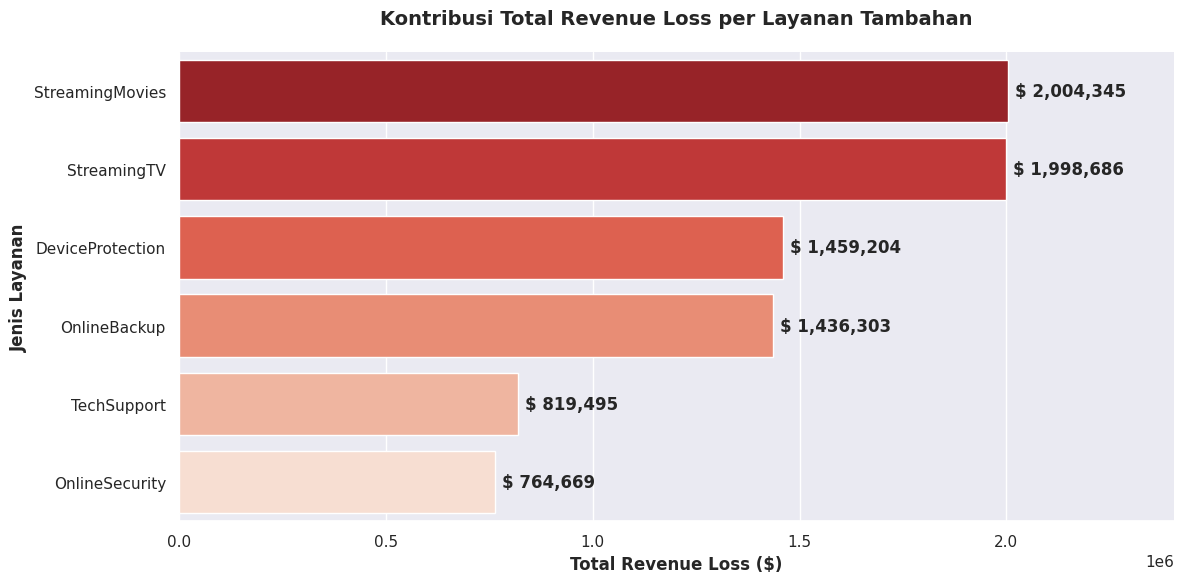

In [ ]:
# ========================================================
# 3. HITUNG LOSS BERDASARKAN LAYANAN TAMBAHAN / HIBURAN
# ========================================================
layanan_tambahan = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

print("\n[2] RINGKASAN KONTRIBUSI REVENUE LOSS DARI PENGGUNA LAYANAN TAMBAHAN (STATUS: YES)")
print("-" * 85)

summary_list = []

for col in layanan_tambahan:
    if col in df_churn.columns:

        vas_loss = df_churn.groupby(col)['TotalCharges'].agg(['sum', 'count'])

        # Ambil data khusus untuk pelanggan Churn yang menggunakan layanan tersebut ('Yes')
        if 'Yes' in vas_loss.index:
            loss_amount = vas_loss.loc['Yes', 'sum']
            cust_count = vas_loss.loc['Yes', 'count']
            pct_contrib = (loss_amount / total_loss_all) * 100

            # Simpan hasilnya ke dalam list
            summary_list.append({
                'Nama Layanan': col,
                'Total Revenue Loss ($)': round(loss_amount, 2),
                'Jumlah Pelanggan Churn': int(cust_count),
                'Kontribusi (%)': round(pct_contrib, 2)
            })

# Mengubah list menjadi DataFrame gabungan dan mengurutkan dari loss terbesar
df_vas_summary = pd.DataFrame(summary_list).sort_values(by='Total Revenue Loss ($)', ascending=False)

# Tampilkan tabel terpadu
print(df_vas_summary.to_string(index=False, formatters={
    'Total Revenue Loss ($)': lambda x: f"${x:,.2f}",
    'Kontribusi (%)': lambda x: f"{x:.2f}%"
}))
print("-" * 85)

# ========================================================
# VISUALISASI KONTRIBUSI REVENUE LOSS
# ========================================================
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='Total Revenue Loss ($)',
    y='Nama Layanan',
    data=df_vas_summary,
    palette='Reds_r'
)

# Tambahkan label nilai di ujung bar
for i in ax.containers:
    ax.bar_label(i, fmt='$ {:,.0f}', padding=5, fontweight='bold')

plt.title('Kontribusi Total Revenue Loss per Layanan Tambahan', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Total Revenue Loss ($)', fontweight='bold')
plt.ylabel('Jenis Layanan', fontweight='bold')
plt.xlim(0, df_vas_summary['Total Revenue Loss ($)'].max() * 1.2)

sns.despine()
plt.tight_layout()
plt.show()

Berdasarkan analisis kontribusi produk, kebocoran uang terbesar perusahaan secara mutlak berasal dari pelanggan yang berlangganan **Internet Fiber Optic**, yang menyumbang kerugian luar biasa besar yaitu **86,74% (sekitar $2,48 Juta)** dari total seluruh pendapatan yang hilang. Menariknya, jika dibedah berdasarkan fasilitas tambahan yang digunakan oleh pelanggan yang kabur, mayoritas dari mereka adalah penikmat layanan hiburan seperti **Streaming Movies (70,01%)** dan **StreamingTV (69,81%)**. Sebaliknya, pelanggan yang menggunakan fitur keamanan seperti *Tech Support* dan *Online Security* justru persentase kaburnya sangat kecil (di bawah 30%).

Sederhananya, infografis ini menunjukkan sebuah pola yang jelas: **Pelanggan premium yang membeli paket internet mahal (Fiber Optic) sekaligus berlangganan paket hiburan film/TV adalah kelompok yang paling rapuh dan paling banyak kabur.** Hal ini mengindikasikan adanya masalah serius pada kualitas kestabilan jaringan internet Fiber Optic kita atau harga paket bundling hiburan yang dirasa sudah tidak sebanding dengan kualitasnya. Rekomendasinya, daripada fokus memberikan promo ke pelanggan biasa, perusahaan harus segera melakukan intervensi dan perbaikan layanan khusus untuk cluster pengguna "Fiber Optic + Streaming" ini agar kerugian jutaan dolar tidak terus membengkak.

### c. Revenue Loss by Phone Service

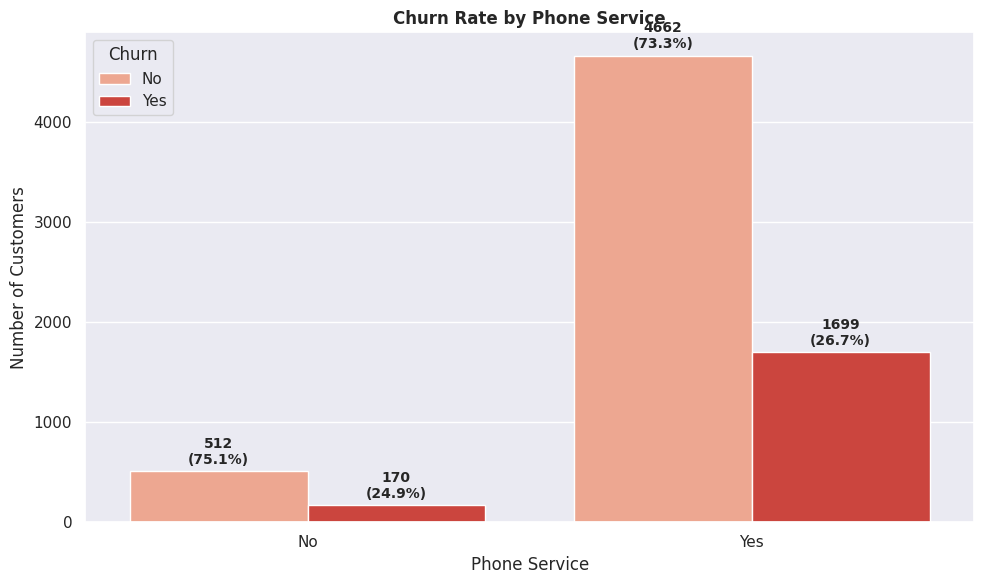

In [ ]:
# Churn by Phone Service
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_final, x='PhoneService', hue='Churn', palette='Reds')

# Menghitung total per kategori PhoneService untuk dasar persentase
total_per_category = df_final.groupby('PhoneService')['Churn'].count()

# Menambahkan label jumlah dan persentase di atas batang
for container in ax.containers:
    # Ambil status Churn (No/Yes) dari nama container (legend)
    legend_label = container.get_label()

    labels = []
    for bar in container:
        height = bar.get_height()
        if height > 0:
            # Ambil total berdasarkan kategori PhoneService di sumbu X
            x_val = bar.get_x() + bar.get_width() / 2
            phone_service_type = 'Yes' if x_val > 0.5 else 'No' # Cek posisi batang di x-axis

            total = total_per_category[phone_service_type]
            percentage = (height / total) * 100

            # Format label: "Jumlah (Persentase%)"
            labels.append(f'{int(height)}\n({percentage:.1f}%)')
        else:
            labels.append('')

    ax.bar_label(container, labels=labels, fontsize=10, fontweight='bold', padding=3)

plt.title('Churn Rate by Phone Service', fontsize=12, fontweight='bold')
plt.xlabel('Phone Service')
plt.ylabel('Number of Customers')

# Mengatur posisi legend agar tidak menutupi grafik
plt.legend(title='Churn', loc='upper left')
plt.tight_layout()
plt.show()

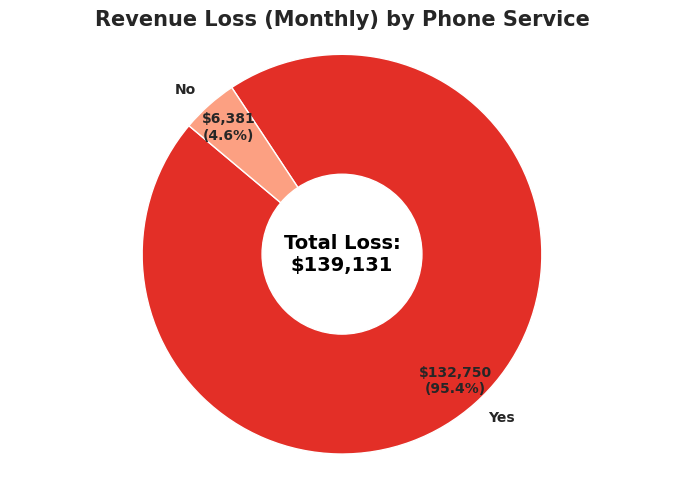

In [ ]:
# Menghitung revenue loss berdasarkan Phone Service
df_churn = df_final[df_final['Churn'] == 'Yes']
revenue_loss_check = df_churn.groupby('PhoneService')['MonthlyCharges'].sum().sort_values(ascending=False)
total_loss = revenue_loss_check.sum()

labels = revenue_loss_check.index
sizes = revenue_loss_check.values
plt.figure(figsize=(7, 5))

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = (pct*total/100.0)
        return f'${val:,.0f}\n({pct:.1f}%)'
    return my_autopct

plt.pie(sizes, labels=labels, autopct=make_autopct(sizes), startangle=140,
        colors=sns.color_palette('Reds_r', len(labels)), pctdistance=0.85,
        textprops={'fontweight': 'bold', 'fontsize': 10})

centre_circle = plt.Circle((0,0), 0.40, fc='white')
plt.gcf().gca().add_artist(centre_circle)

plt.text(0, 0, f'Total Loss:\n${total_loss:,.0f}', ha='center', va='center',
         fontweight='bold', fontsize=14, color='black')

plt.title('Revenue Loss (Monthly) by Phone Service', fontweight='bold', fontsize=15)
plt.axis('equal')
plt.tight_layout()
plt.show()

Analisis :
Meskipun persentase pelanggan yang Churn hampir sama, sektor Phone Services menjadi sumber utama Revenue Loss karena menyumbang $132.750 (95,4%) dari total kerugian perusahaan yang mencapai $139.131/bulan.

Rekomedasi :
Prioritaskan anggaran retensi untuk mengevaluasi tarif paket telepon, apa lebih menarik dari kompetitor atau tidak. Berikan promo sebelum masa kontrak habis, serta mendorong strategi Multiple Lines agar pelanggan lebih terikat dan tidak mudah pindah ke kompetitor.

### d. Revenue Loss by Offer

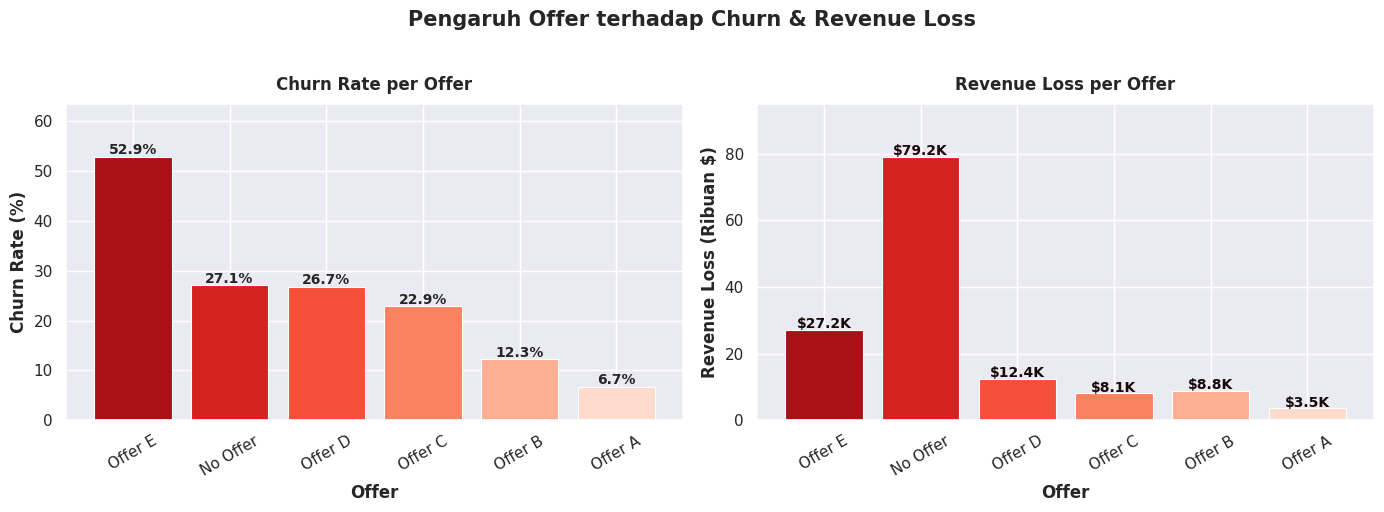

          Churn  Total      Rate%
Offer                            
Offer E     426    805  52.919255
No Offer   1051   3877  27.108589
Offer D     161    602  26.744186
Offer C      95    415  22.891566
Offer B     101    824  12.257282
Offer A      35    520   6.730769


In [ ]:
# Pengaruh Offer terhadap Churn & Revenue Loss
if 'Offer' in df_viz.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Pengaruh Offer terhadap Churn & Revenue Loss', fontsize=15, fontweight='bold', y=1.02)

    # --- Panel kiri: Churn Rate per Offer ---
    offer_churn = df_viz.groupby('Offer')['Churn'].agg(['sum','count'])
    offer_churn['rate'] = offer_churn['sum'] / offer_churn['count'] * 100
    offer_churn = offer_churn.sort_values('rate', ascending=False)

    palette_kiri = sns.color_palette("Reds_r", n_colors=len(offer_churn))

    bars = axes[0].bar(offer_churn.index, offer_churn['rate'],
                       color=palette_kiri, edgecolor='white', linewidth=0.8)

    for bar, val in zip(bars, offer_churn['rate']):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

    axes[0].set_xlabel('Offer', fontweight='bold')
    axes[0].set_ylabel('Churn Rate (%)', fontweight='bold')
    axes[0].set_title('Churn Rate per Offer', fontsize=12, fontweight='bold', pad=10)
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].set_ylim(0, offer_churn['rate'].max() * 1.2)

    # --- Panel kanan: Revenue Loss per Offer ---
    if 'RevenueLoss' in df_viz.columns:
        offer_rl = df_viz.groupby('Offer')['RevenueLoss'].sum().reindex(offer_churn.index)

        palette_kanan = sns.color_palette("Reds_r", n_colors=len(offer_rl))

        bars2 = axes[1].bar(offer_rl.index, offer_rl.values / 1e3,
                            color=palette_kanan, edgecolor='white', linewidth=0.8)

        for bar, val in zip(bars2, offer_rl.values):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                         f'${val/1e3:.1f}K', ha='center', fontsize=10, fontweight='bold', color="#190808")

        axes[1].set_xlabel('Offer', fontweight='bold')
        axes[1].set_ylabel('Revenue Loss (Ribuan $)', fontweight='bold')
        axes[1].set_title('Revenue Loss per Offer', fontsize=12, fontweight='bold', pad=10)
        axes[1].tick_params(axis='x', rotation=30)
        axes[1].set_ylim(0, offer_rl.max()/1e3 * 1.2)

    plt.tight_layout()
    plt.show()

    print(offer_churn[['sum','count','rate']].rename(columns={'sum':'Churn','count':'Total','rate':'Rate%'}))

**HASIL ANALISIS**
*3*. Offer vs Churn & Revenue Loss
- Evaluasi ulang atau hentikan Offer E. Churn rate 52.9% menunjukkan Offer E tidak efektif sama sekali sebagai alat retensi. Anggaran yang dihabiskan untuk Offer E lebih baik dialihkan ke perluasan Offer A, yang terbukti menurunkan churn ke 6.7%.
- Fokus pada pemberian offer kepada pelanggan No Offer sekarang. $79.2K revenue loss dari No Offer. Mereka adalah high-value customers yang tidak ada program retensi apapun. Dapat difokuskan ke Offer A (churn rate 6.7%) atau Offer B (12.3%)
- Replikasi model Offer A ke skala lebih besar
Offer A adalah yang paling efektif (6.7% churn rate). Investigasi karakteristik Offer A: apa yang membedakannya dari yang lain, apakah diskon lebih besar, bundle layanan tambahan, perpanjangan kontrak. Setelah ditelusuri, replikasi ke lebih banyak pelanggan terutama ke segmen No Offer


## **6. Apakah revenue loss didominasi pelanggan lama atau pelanggan baru**

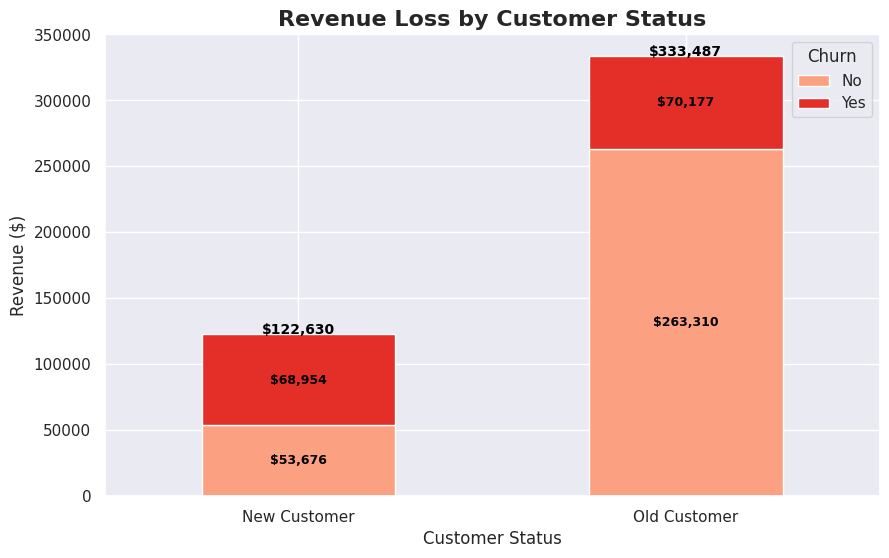

In [ ]:
revenue_loss_status = (df_final.groupby(['Customer_Status', 'Churn'])['MonthlyCharges'].sum().unstack())

ax = revenue_loss_status.plot(
    kind='bar', stacked=True, color=sns.color_palette('Reds', 2), figsize=(10,6)
    )

# Label pada setiap stack
for container in ax.containers:
    labels = [
        f'${v:,.0f}' if v > 0 else ''
        for v in container.datavalues
        ]
    ax.bar_label(
        container, labels=labels, label_type='center',
        fontsize=9, color='black', fontweight='bold'
        )

totals = revenue_loss_status.sum(axis=1)

# Label total di atas bar
for i, total in enumerate(totals):
    ax.text(
        i, total + 500, f'${total:,.0f}',
        ha='center', fontweight='bold', fontsize=10, color='black'
    )

plt.title('Revenue Loss by Customer Status',
          fontsize=16, weight='bold')

plt.xlabel('Customer Status')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

**Kesimpulan:**

Berdasarkan visualisasi tersebut, terlihat bahwa Old Customer memberikan kontribusi besar bagi perusahaan sebesar \$333.487, namun tetap mengalami churn sebesar $70.177, sehingga kehilangan pelanggan lama dapat memberikan dampak finansial yang signifikan bagi perusahaan.

Sementara itu, New Customer memiliki total revenue yang lebih kecil yaitu \$122.630, tetapi nilai revenue loss akibat churn hampir setara dengan pelanggan lama, yaitu sebesar $68.954, yang menunjukkan bahwa pelanggan baru memiliki kecenderungan churn yang lebih tinggi.

**Rekomendasi:**

Perusahaan harus segera memperketat proses onboarding dan memberikan pendampingan intensif bagi pelanggan baru untuk menekan angka churn di awal dengan menyediakan panduan produk yang lebih interaktif, layanan bantuan kilat, serta evaluasi kesesuaian ekspektasi iklan dengan realitas layanan guna menekan tingginya persentase churn di awal.


## **7. Berapa perkiraan revenue yang hilang bila churn naik satu persen**

In [ ]:
# Set Max CAC dan Max CRC
df_final['estimated_cac_max'] = df_final['CLTV'] * 0.30
df_final['estimated_crc_max'] = df_final['CLTV'] * 0.10

# Kelompokkan data untuk melihat total CLTV dan estimasi biaya per status
summary_churn = df_final.groupby('Churn').agg(
    jumlah_pelanggan=('customerID', 'count'),
    total_cltv=('CLTV', 'sum'),
    total_estimasi_crc=('estimated_crc_max', 'sum')
).reset_index()

print("--- RINGKASAN KESEHATAN PELANGGAN & ANGGARAN ---")
print(summary_churn.to_string(index=False, formatters={
    'total_cltv': lambda x: f"${x:,.0f}",
    'total_estimasi_crc': lambda x: f"${x:,.0f}"
    }))

--- RINGKASAN KESEHATAN PELANGGAN & ANGGARAN ---
Churn  jumlah_pelanggan  total_cltv total_estimasi_crc
   No              5174 $23,236,027         $2,323,603
  Yes              1869  $7,755,256           $775,526


In [ ]:
# Filtering Customer Churn
df_churn = df_final[df_final['Churn'] == 'Yes']

# Menghitung Rata-rata
mean_cltv = df_churn['CLTV'].mean()
mean_cac = df_churn['estimated_cac_max'].mean()
mean_crc = df_churn['estimated_crc_max'].mean()
total_pelanggan_churn = len(df_churn)

print("="*80)
print(f"   RANGKUMAN RATA-RATA BIAYA PER PELANGGAN CHURN (Total: {total_pelanggan_churn} User)")
print("="*80)
print(f"Rata-rata Nilai CLTV yang Hilang     : ${mean_cltv:,.0f}")
print(f"Rata-rata Batasan Anggaran CAC       : ${mean_cac:,.0f}")
print(f"Rata-rata Batasan Anggaran CRC       : ${mean_crc:,.0f}")
print("="*80)


   RANGKUMAN RATA-RATA BIAYA PER PELANGGAN CHURN (Total: 1869 User)
Rata-rata Nilai CLTV yang Hilang     : $4,149
Rata-rata Batasan Anggaran CAC       : $1,245
Rata-rata Batasan Anggaran CRC       : $415


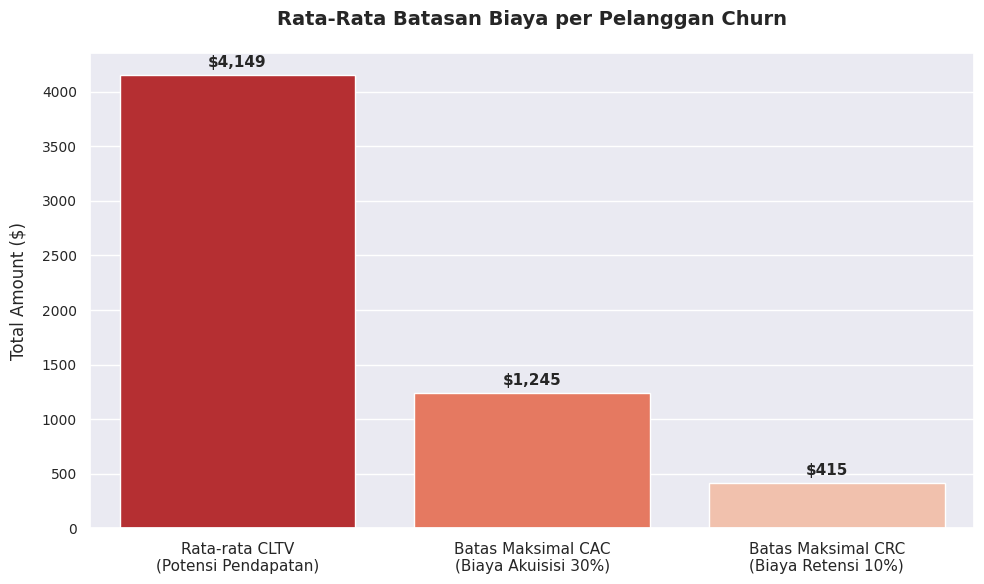

In [ ]:
categories = [
    'Rata-rata CLTV\n(Potensi Pendapatan)',
    'Batas Maksimal CAC\n(Biaya Akuisisi 30%)',
    'Batas Maksimal CRC\n(Biaya Retensi 10%)'
]
values = [mean_cltv, mean_cac, mean_crc]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=categories, y=values, palette='Reds_r')

for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11,
                weight='bold')

plt.title(f'Rata-Rata Batasan Biaya per Pelanggan Churn',
          fontsize=14, pad=20, weight='bold')
plt.ylabel('Total Amount ($)', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


### Simulasi dampak finansial jika Churn naik 1%

In [ ]:
# 1. Hitung total pelanggan yang saat ini masih aktif
total_pelanggan_aktif = df_final[df_final['Churn'] == 'No'].shape[0]

# 2. Hitung jumlah pelanggan yang mewakili kenaikan 1% Churn
pelanggan_1_persen = round(total_pelanggan_aktif * 0.01)

# 3. Ambil nilai rata-rata CLTV
rata_rata_cltv = df_churn['CLTV'].mean()

# 4. Hitung total perkiraan revenue yang hilang (Potensi Kerugian)
revenue_hilang_1_persen = pelanggan_1_persen * rata_rata_cltv

print("==================================================================")
print("          PROYEKSI DAMPAK FINANSIAL: JIKA CHURN NAIK 1%          ")
print("==================================================================")
print(f"Total Basis Pelanggan Aktif Saat Ini : {total_pelanggan_aktif} User")
print(f"Estimasi Jumlah Pelanggan (1%)        : {pelanggan_1_persen} User")
print(f"Rata-rata Kerugian per Pelanggan (CLTV): ${rata_rata_cltv:,.2f}")
print("------------------------------------------------------------------")
print(f"PERKIRAAN REVENUE YANG HILANG         : ${revenue_hilang_1_persen:,.2f}")
print("==================================================================")

          PROYEKSI DAMPAK FINANSIAL: JIKA CHURN NAIK 1%          
Total Basis Pelanggan Aktif Saat Ini : 5174 User
Estimasi Jumlah Pelanggan (1%)        : 52 User
Rata-rata Kerugian per Pelanggan (CLTV): $4,149.41
------------------------------------------------------------------
PERKIRAAN REVENUE YANG HILANG         : $215,769.56


setiap kenaikan **1%** pada angka *churn rate* akan membawa dampak kerugian finansial yang signifikan bagi perusahaan. Kenaikan 1% tersebut setara dengan hilangnya **52 pelanggan aktif** secara instan (dari total basis 5,174 pelanggan yang saat ini bertahan). Mengingat setiap pelanggan yang *churn* membawa kerugian potensi pendapatan jangka panjang (*Mean Customer Lifetime Value* atau CLTV) sebesar **\$4,149.41**, maka perkiraan total *revenue* masa depan yang akan lenyap dari perputaran bisnis perusahaan adalah sebesar **$215,769.56**

### Simulasi persentase kerugian yang bisa di kurangi

       SIMULASI POTENSI REVENUE YANG BISA DISELAMATKAN     
                Skenario  Tingkat Keberhasilan (%)  User Berhasil Diselamatkan Kerugian yang Berhasil Dikurangi ($)
Tingkat Keberhasilan 10%                        10                          81                          $376,480.50
Tingkat Keberhasilan 30%                        30                         243                        $1,129,441.50
Tingkat Keberhasilan 50%                        50                         405                        $1,882,402.50


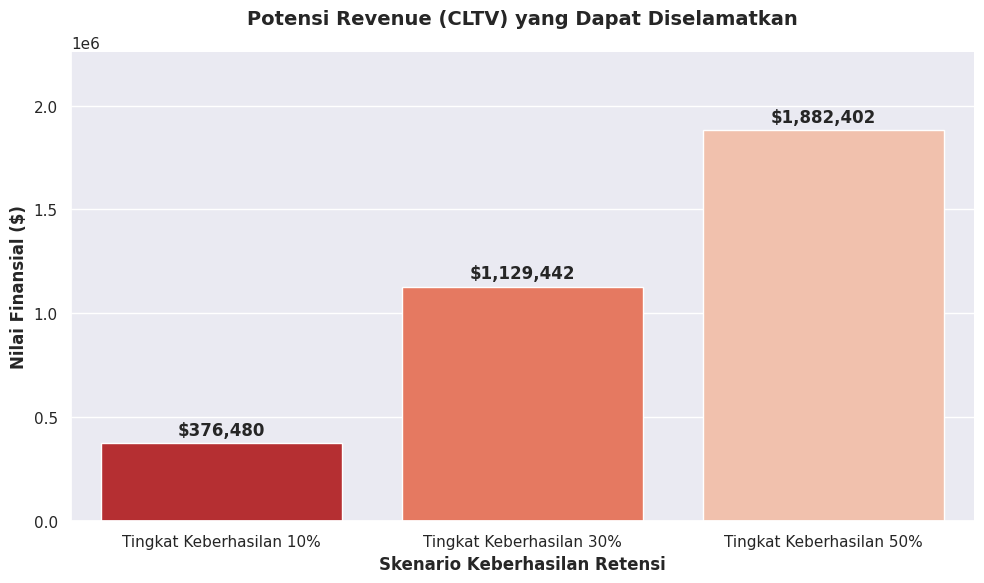

In [ ]:
# DASAR DATA (DIAMBIL DARI HASIL FILTER SEBELUMNYA)

jumlah_user_kritis = df_target_prioritas_utama.shape[0]  # 811
total_cltv_terancam = df_target_prioritas_utama['CLTV'].sum()  # $3,764,805.00
max_crc_per_user = 415  # Batas budget CRC dari analisis nomor 7

#  SIMULASI PERSENTASE KERUGIAN YANG BISA DIKURANGI
scenarios = {
    'Skenario': ['Tingkat Keberhasilan 10%', 'Tingkat Keberhasilan 30%', 'Tingkat Keberhasilan 50%'],
    'Tingkat Keberhasilan (%)': [10, 30, 50]
}

df_simulasi = pd.DataFrame(scenarios)

# Hitung jumlah user yang berhasil diselamatkan
df_simulasi['User Berhasil Diselamatkan'] = (df_simulasi['Tingkat Keberhasilan (%)'] / 100 * jumlah_user_kritis).astype(int)

# Hitung total kerugian finansial jangka panjang (CLTV) yang berhasil diselamatkan
df_simulasi['Kerugian yang Berhasil Dikurangi ($)'] = df_simulasi['Tingkat Keberhasilan (%)'] / 100 * total_cltv_terancam

print("===========================================================")
print("       SIMULASI POTENSI REVENUE YANG BISA DISELAMATKAN     ")
print("===========================================================")
print(df_simulasi.to_string(index=False, formatters={'Kerugian yang Berhasil Dikurangi ($)': '${:,.2f}'.format}))


# VISUALISASI HASIL SIMULASI
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Skenario', y='Kerugian yang Berhasil Dikurangi ($)', data=df_simulasi, palette='Reds_r')

# Tambahkan label nilai di atas bar
for i in ax.containers:
    ax.bar_label(i, fmt='${:,.0f}', fontweight='bold', padding=3)

plt.title('Potensi Revenue (CLTV) yang Dapat Diselamatkan', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Nilai Finansial ($)', fontweight='bold')
plt.xlabel('Skenario Keberhasilan Retensi', fontweight='bold')
plt.ylim(0, df_simulasi['Kerugian yang Berhasil Dikurangi ($)'].max() * 1.2)

sns.despine()
plt.tight_layout()
plt.show()

Jika program penyelamatan (Early Warning System) ini dijalankan khusus untuk 811 pelanggan kritis ini, diatas adalah simulasi persentase kerugian yang bisa dikurangi dari total potensi kehilangan $3.76 Juta.

Dengan memprioritaskan program retensi hanya pada 811 pelanggan kritis di kluster ini, target moderat keberhasilan sebesar 30% saja sudah mampu menyelamatkan perusahaan dari kerugian jangka panjang sebesar $1.12 Juta.

### Simulasi Alokasi Anggaran Retensi

In [ ]:
#  CODING ALOKASI STRATEGI BUDGET (CRC ALLOCATION)

# Total budget maksimal yang aman dikeluarkan perusahaan untuk 811 orang ini
total_budget_ceiling = jumlah_user_kritis * max_crc_per_user

# Kita buat simulasi alokasi program retensi konkret yang biayanya di bawah $415
rencana_action = {
    'Jenis Action Program Retensi': [
        '1. Voucher Kompensasi & Audit Jaringan (Potongan $15 x 10 Bulan)',
        '2. Subsidi Free Akses Fitur Keamanan (TechSupport/Security) 1 Tahun',
        'SISA BUDGET CADANGAN AMAN (Buffer)'
    ],
    'Estimasi Biaya / User ($)': [150, 50, (max_crc_per_user - 150 - 50)]
}

df_budget = pd.DataFrame(rencana_action)
df_budget['Total Pengeluaran Kluster (811 User) ($)'] = df_budget['Estimasi Biaya / User ($)'] * jumlah_user_kritis

print("\n=========================================================")
print("       SIMULASI ALOKASI ANGGARAN RETENSI (MAX $415/USER)   ")
print("===========================================================")
print(df_budget.to_string(index=False, formatters={
    'Estimasi Biaya / User ($)': '${:,.2f}'.format,
    'Total Pengeluaran Kluster (811 User) ($)': '${:,.2f}'.format
}))
print(f"\nTOTAL MAKSIMAL PAGU ANGGARAN (CEILING): ${total_budget_ceiling:,.2f}")
print("==================================================================")


       SIMULASI ALOKASI ANGGARAN RETENSI (MAX $415/USER)   
                                       Jenis Action Program Retensi Estimasi Biaya / User ($) Total Pengeluaran Kluster (811 User) ($)
   1. Voucher Kompensasi & Audit Jaringan (Potongan $15 x 10 Bulan)                   $150.00                              $121,650.00
2. Subsidi Free Akses Fitur Keamanan (TechSupport/Security) 1 Tahun                    $50.00                               $40,550.00
                                 SISA BUDGET CADANGAN AMAN (Buffer)                   $215.00                              $174,365.00

TOTAL MAKSIMAL PAGU ANGGARAN (CEILING): $336,565.00


batas maksimal biaya penyelamatan (CRC Ceiling) adalah \$415 per pelanggan. Dengan total 811 pelanggan kritis, total pagu anggaran maksimal yang aman digunakan adalah $415 × 811 = $336,565.

karakteristik kluster ini adalah: pelanggan bernilai tinggi (High/Mid Value) yang menggunakan Fiber Optic (Internet Mahal) dan sedang kurang puas (Score 3).

Berikut adalah rekomendasi Action Plan yang biayanya di bawah \$415 per orang:
1. Program "Loyalty Upgrade & Network Audit" (Estimasi Biaya: ~$100 - $150 per user):
Karena mereka pengguna Fiber Optic yang kecewa, kirimkan teknisi secara proaktif untuk mengaudit kecepatan internet di rumah mereka secara gratis, lalu berikan voucher kompensasi potongan tagihan sebesar \$15 per bulan selama 10 bulan ke depan sebagai permohonan maaf atas ketidaknyamanan.
2. Subsidi Bundling Layanan Premium (Estimasi Biaya: ~$50 per user):
Beri mereka gratis langganan fitur keamanan (Online Security atau Tech Support) selama 1 tahun penuh. karena pelanggan yang memakai fitur keamanan ini terbukti sangat setia dan jarang churn. Ini adalah taktik mengikat pelanggan dengan biaya internal yang sangat murah.

# **CONCLUSION & RECOMENDATION**

## **Conclusion**

### **Analisis Churn & Dampak Finansial**

#### **1. Dampak Finansial & Karakteristik Churn**
* **Kebocoran Pendapatan Bulanan:** Perusahaan kehilangan pendapatan bulanan sebesar **USD 139,130.85 per bulan** (dihitung dari `MonthlyCharges`) akibat pelanggan yang memilih *churn*.
* **Karakteristik Pelanggan Premium:** Pelanggan yang pergi memiliki rata-rata tagihan bulanan sebesar **USD 74.44**, jauh lebih tinggi dibandingkan pelanggan aktif yang rata-rata hanya **USD 61.27**. Hal ini mengindikasikan bahwa perusahaan kehilangan kelompok pelanggan premium (*high-spending*).
* **Akumulasi Kerugian Historis:** Secara historis, akumulasi total kerugian riil dari seluruh pelanggan yang telah *churn* mencapai angka yang sangat masif, yaitu **USD 2,862,926.90** (dihitung dari `TotalCharges`).

#### **2. Titik Kebocoran Layanan Terbesar**
* **Infrastruktur Utama:** Layanan internet *Fiber Optic* menjadi penyumbang utama kegagalan retensi dengan kontribusi mutlak sebesar **86.74%** (sekitar **USD 2.48 Juta**) dari total pendapatan yang hilang.
* **Fasilitas Tambahan:** Jika dibedah berdasarkan fitur tambahan, mayoritas pelanggan yang *churn* merupakan pengguna aktif fitur hiburan seperti *Streaming Movies* (**70.01%**) dan *Streaming TV* (**69.81%**).

#### **3. Efektivitas Program Pemasaran (Offer)**
* **Program Tidak Tepat Sasaran:** Evaluasi terhadap program penawaran saat ini menunjukkan hasil yang belum optimal. **Offer E** mencatat kegagalan terbesar dengan tingkat *churn* (*churn rate*) mencapai **52.9%**.
* **Program Paling Sukses:** Sebaliknya, **Offer A** menjadi program paling sukses dalam mengikat loyalitas pelanggan dengan tingkat *churn* terendah, yaitu hanya **6.7%**.

#### **4. Identifikasi Target Prioritas Utama (Early Warning System)**
* **Kriteria Zona Bahaya (*Swing Voters*):** Melalui proses penyaringan data, ditemukan kelompok pelanggan aktif yang berada di zona kritis dengan kriteria: *Masih Aktif, masuk segmen High/Mid-Value, menggunakan Fiber Optic,* dan memiliki *Satisfaction Score = 3*.
* **Potensi Kerugian Masa Depan:** Kelompok ini berjumlah **811 pengguna** dengan nilai potensi kerugian jangka panjang (*Customer Lifetime Value* atau CLTV) yang dipertaruhkan sangat besar, yaitu mencapai **USD 3,764,805.00** (hampir **USD 3.76 Juta**).

## **Recomendation**

### **Rekomendasi Taktis: Panduan Operasional Customer Retention & Relations**

Rekomendasi taktis ini ditujukan khusus untuk **Customer Retention & Relations Team** sebagai panduan operasional harian guna menekan angka *churn* secara efisien:

#### **1. Eksekusi Program Retensi Berbasis Target Skenario (ROI Pemotongan Kerugian)**
* Tim *Customer Retention* disarankan membidik **Skenario Moderat (Target Sukses 30%)** sebagai KPI awal.
* Dengan berhasil menyelamatkan **243 pelanggan** dari total 811 *user* kritis tersebut, perusahaan secara otomatis dapat langsung memotong potensi kerugian jangka panjang sebesar **USD 1,129,441.50** (Lebih dari **USD 1.1 Juta**).

#### **2. Alokasi Anggaran Taktis di Bawah Batas Maksimal (CRC Ceiling)**
* **Batas Aman Anggaran:** Berdasarkan perhitungan finansial, batas aman pengeluaran biaya penyelamatan (*Customer Retention Cost* / CRC) adalah maksimal **USD 415 per user** (Total pagu anggaran kluster sebesar **USD 336,565.00**).
* **Rekomendasi Alokasi:** Tim operasional direkomendasikan mengalokasikan anggaran gabungan sebesar **USD 200 per user** (sangat aman di bawah batas maksimal USD 415) dengan rincian tindakan:
    * **Voucher Kompensasi & Audit Jaringan (USD 150/user):** Mengirimkan teknisi secara proaktif untuk memastikan kestabilan jalur *Fiber Optic* mereka sekaligus memberikan potongan tagihan **USD 15 selama 10 bulan** sebagai kompensasi rasa kecewa pelanggan.
    * **Subsidi Free Akses Fitur Keamanan (USD 50/user):** Memberikan gratis layanan *Tech Support* atau *Online Security* selama 1 tahun. Berdasarkan data, pelanggan yang mengaktifkan fitur ini terbukti memiliki tingkat loyalitas yang tinggi.
* **Efisiensi Finansial:** Strategi ini menyisakan **Sisa Budget Cadangan Aman (Buffer) sebesar USD 215 per user** yang menjaga keuangan perusahaan tetap sehat dan menguntungkan (*High ROI*).

#### **3. Restrukturisasi Kebijakan Produk dan Pemasaran**
* **Evaluasi Program Gagal:** Segera lakukan evaluasi mendalam dan hentikan perputaran program **Offer E** yang memicu tingginya angka *churn*.
* **Replikasi Program Sukses:** Duplikasi atau replikasi struktur, pola kontrak, serta skema *benefit* dari **Offer A** untuk diterapkan pada segmentasi pasar lainnya karena formula ini terbukti paling sukses mempertahankan pelanggan.